In [541]:
d.advert <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/advert.dat",
header = TRUE)
ts.advert <- ts(log(d.advert[, "ADVERT"]), start = 1907)
ts.sales <- ts(log(d.advert[, "SALES"]), start = 1907)


In [542]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

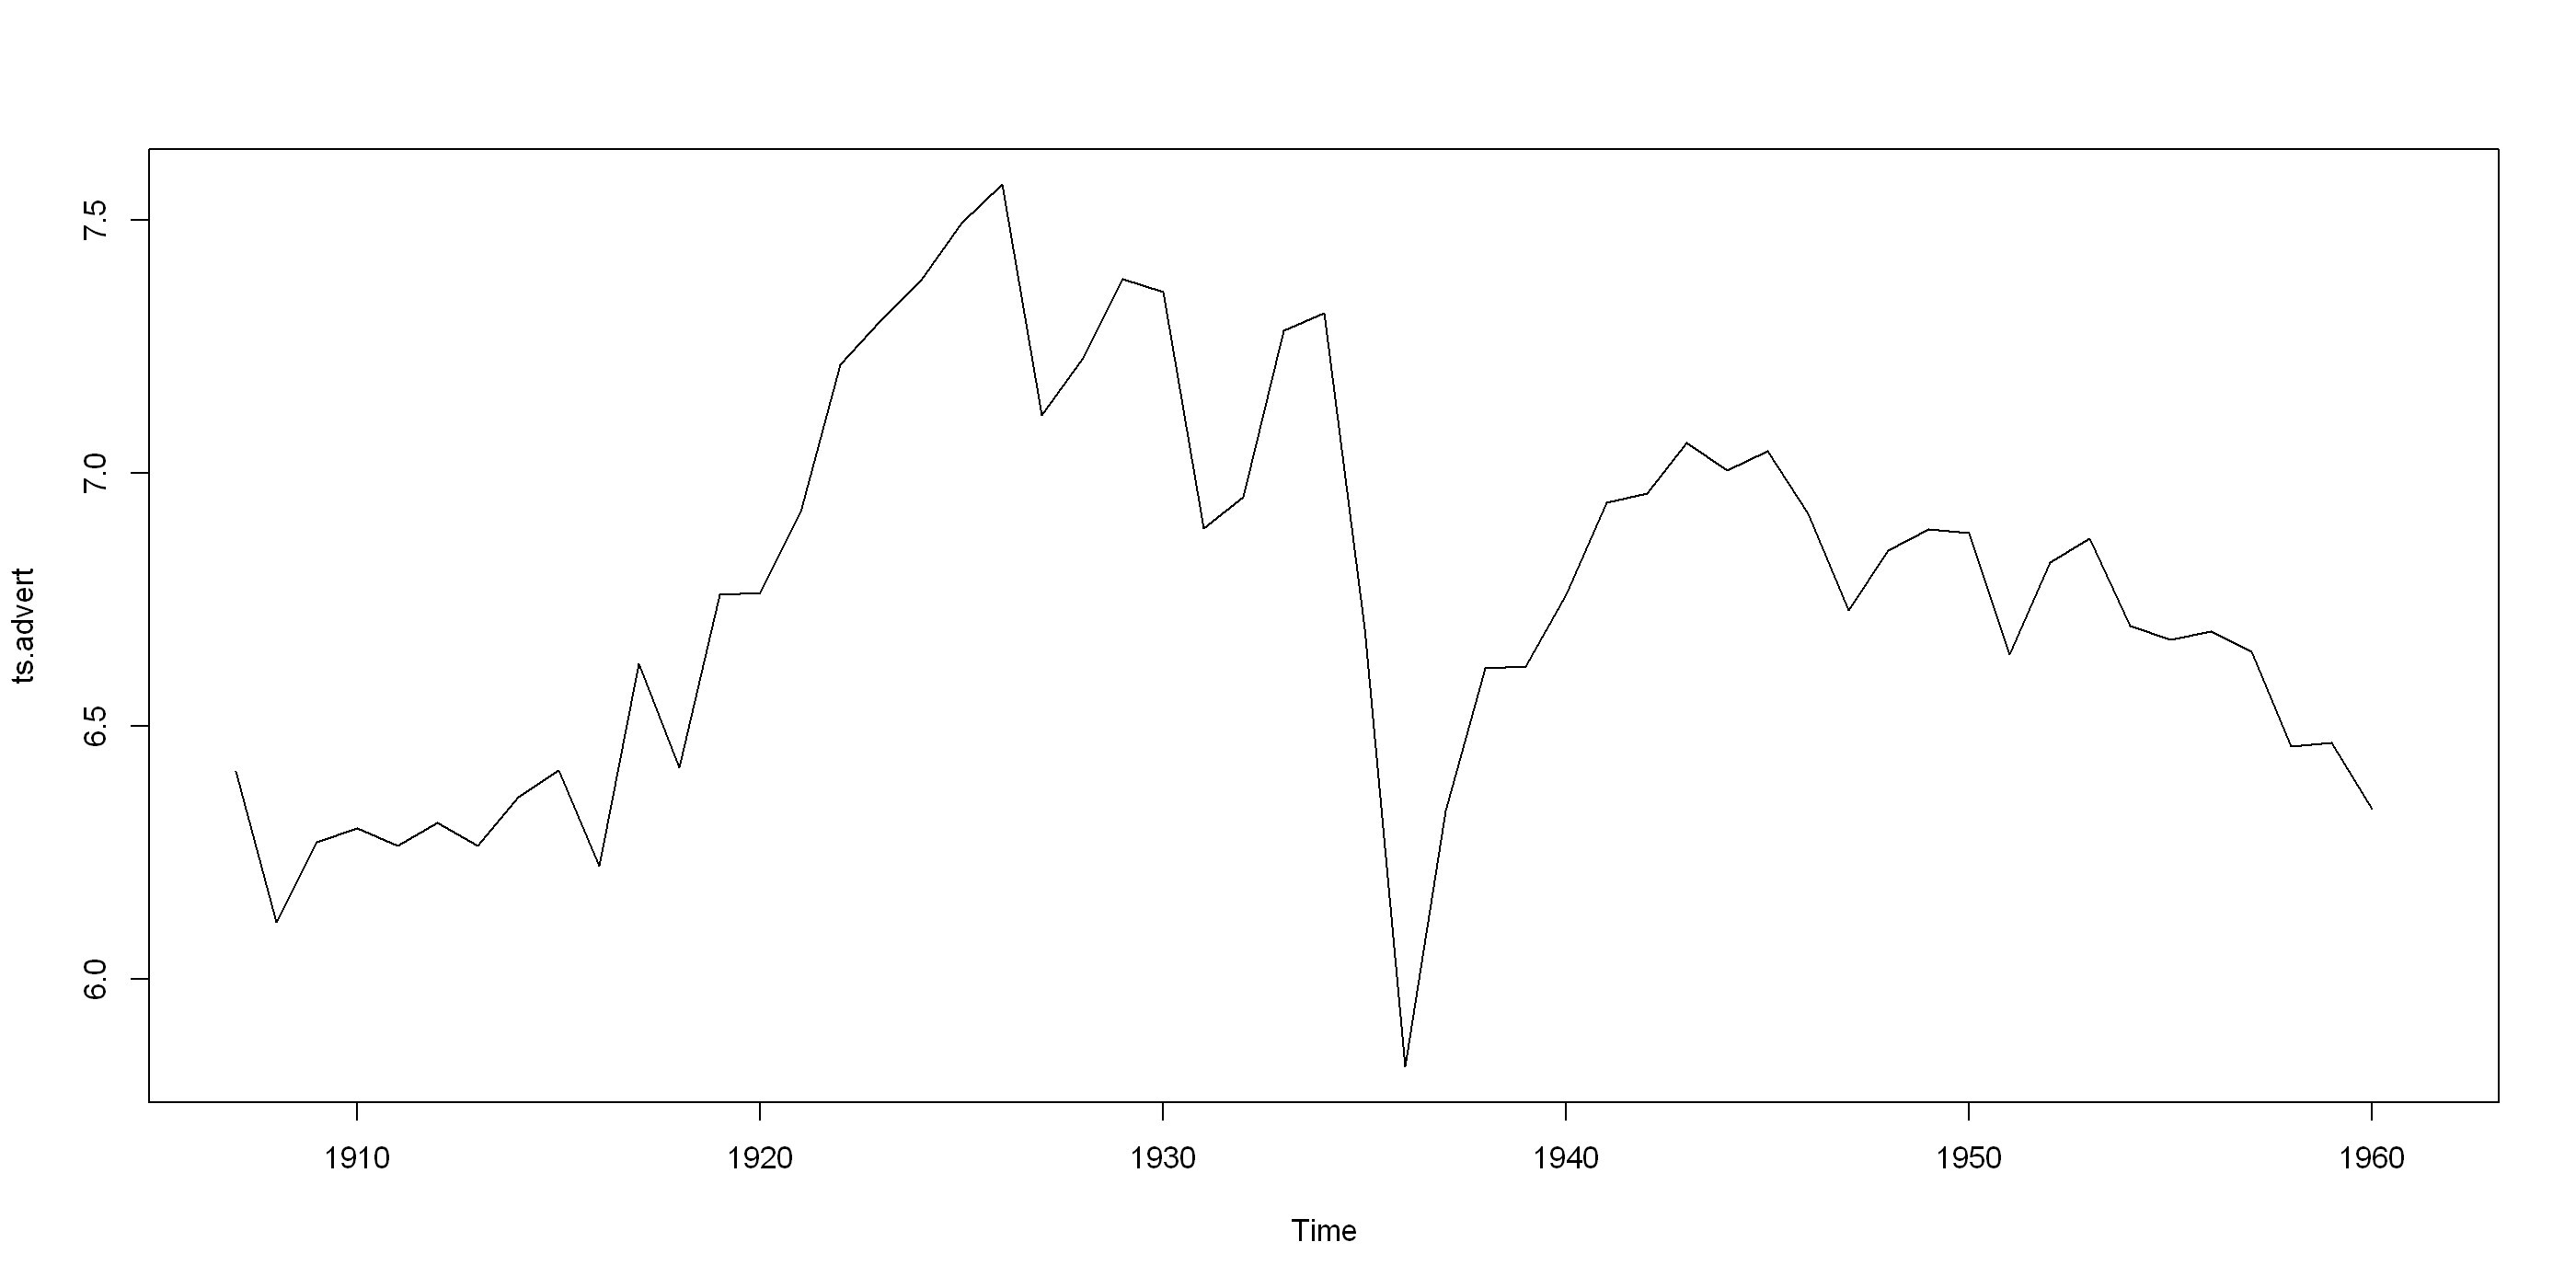

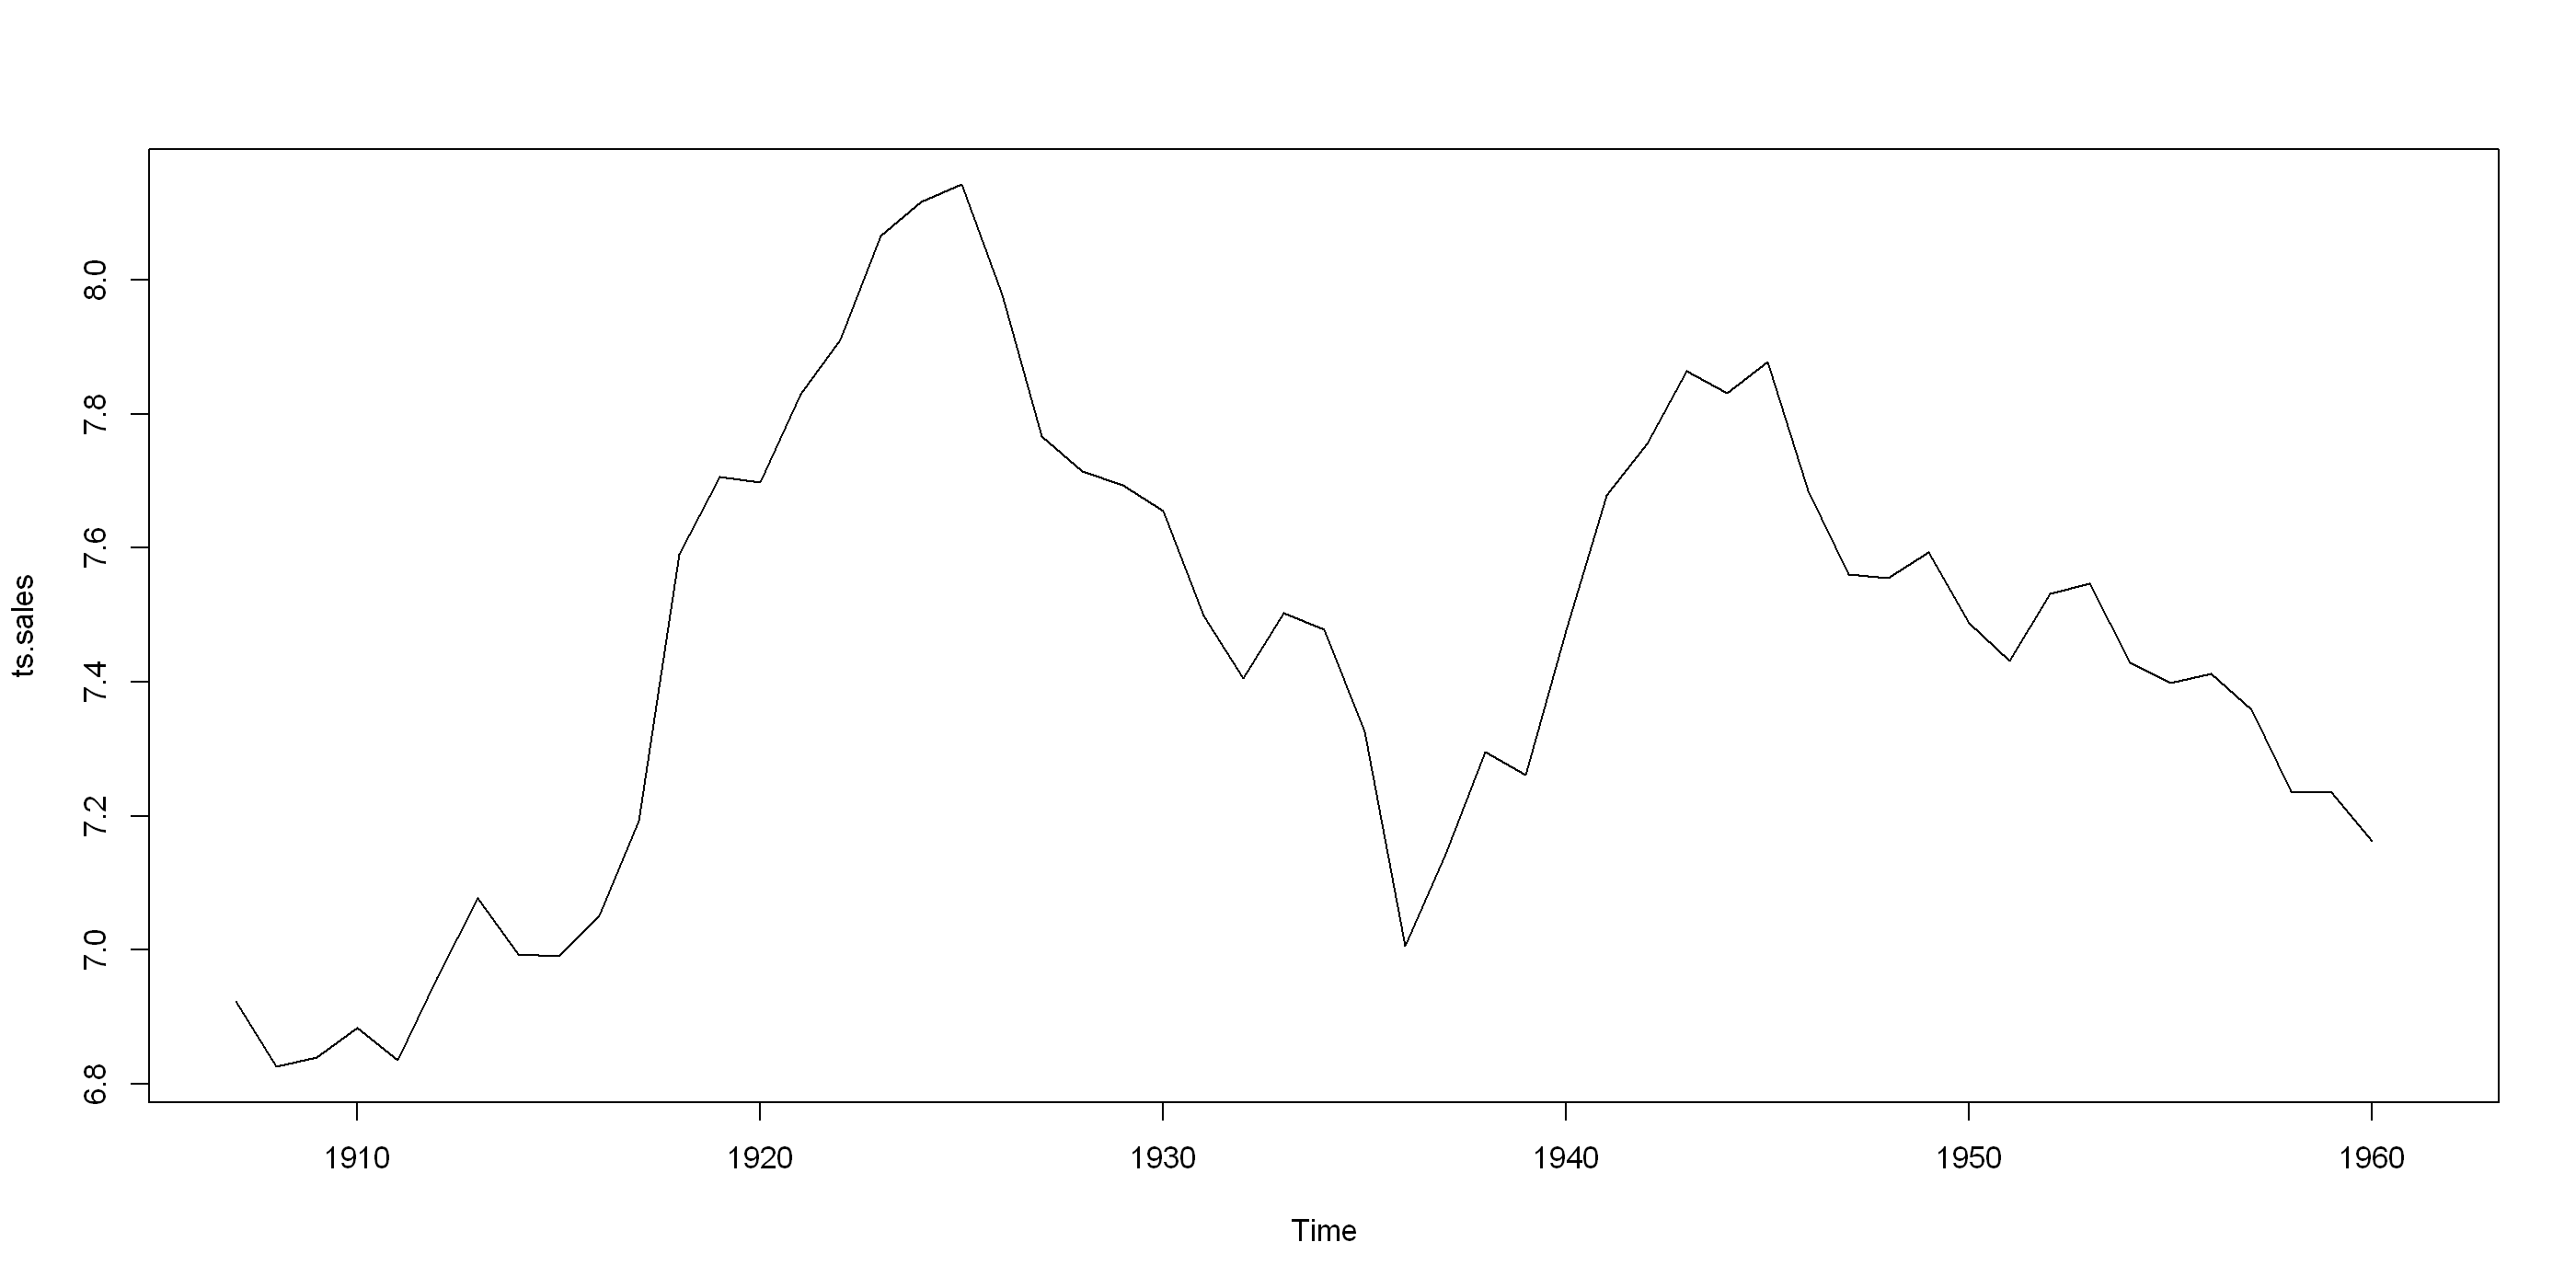

In [543]:
plot(ts.advert)
plot(ts.sales)

In [544]:
ts.adv.d1 <- diff(ts.advert)
ts.sal.d1 <- diff(ts.sales)

In [545]:
n <- length(ts.adv.d1)

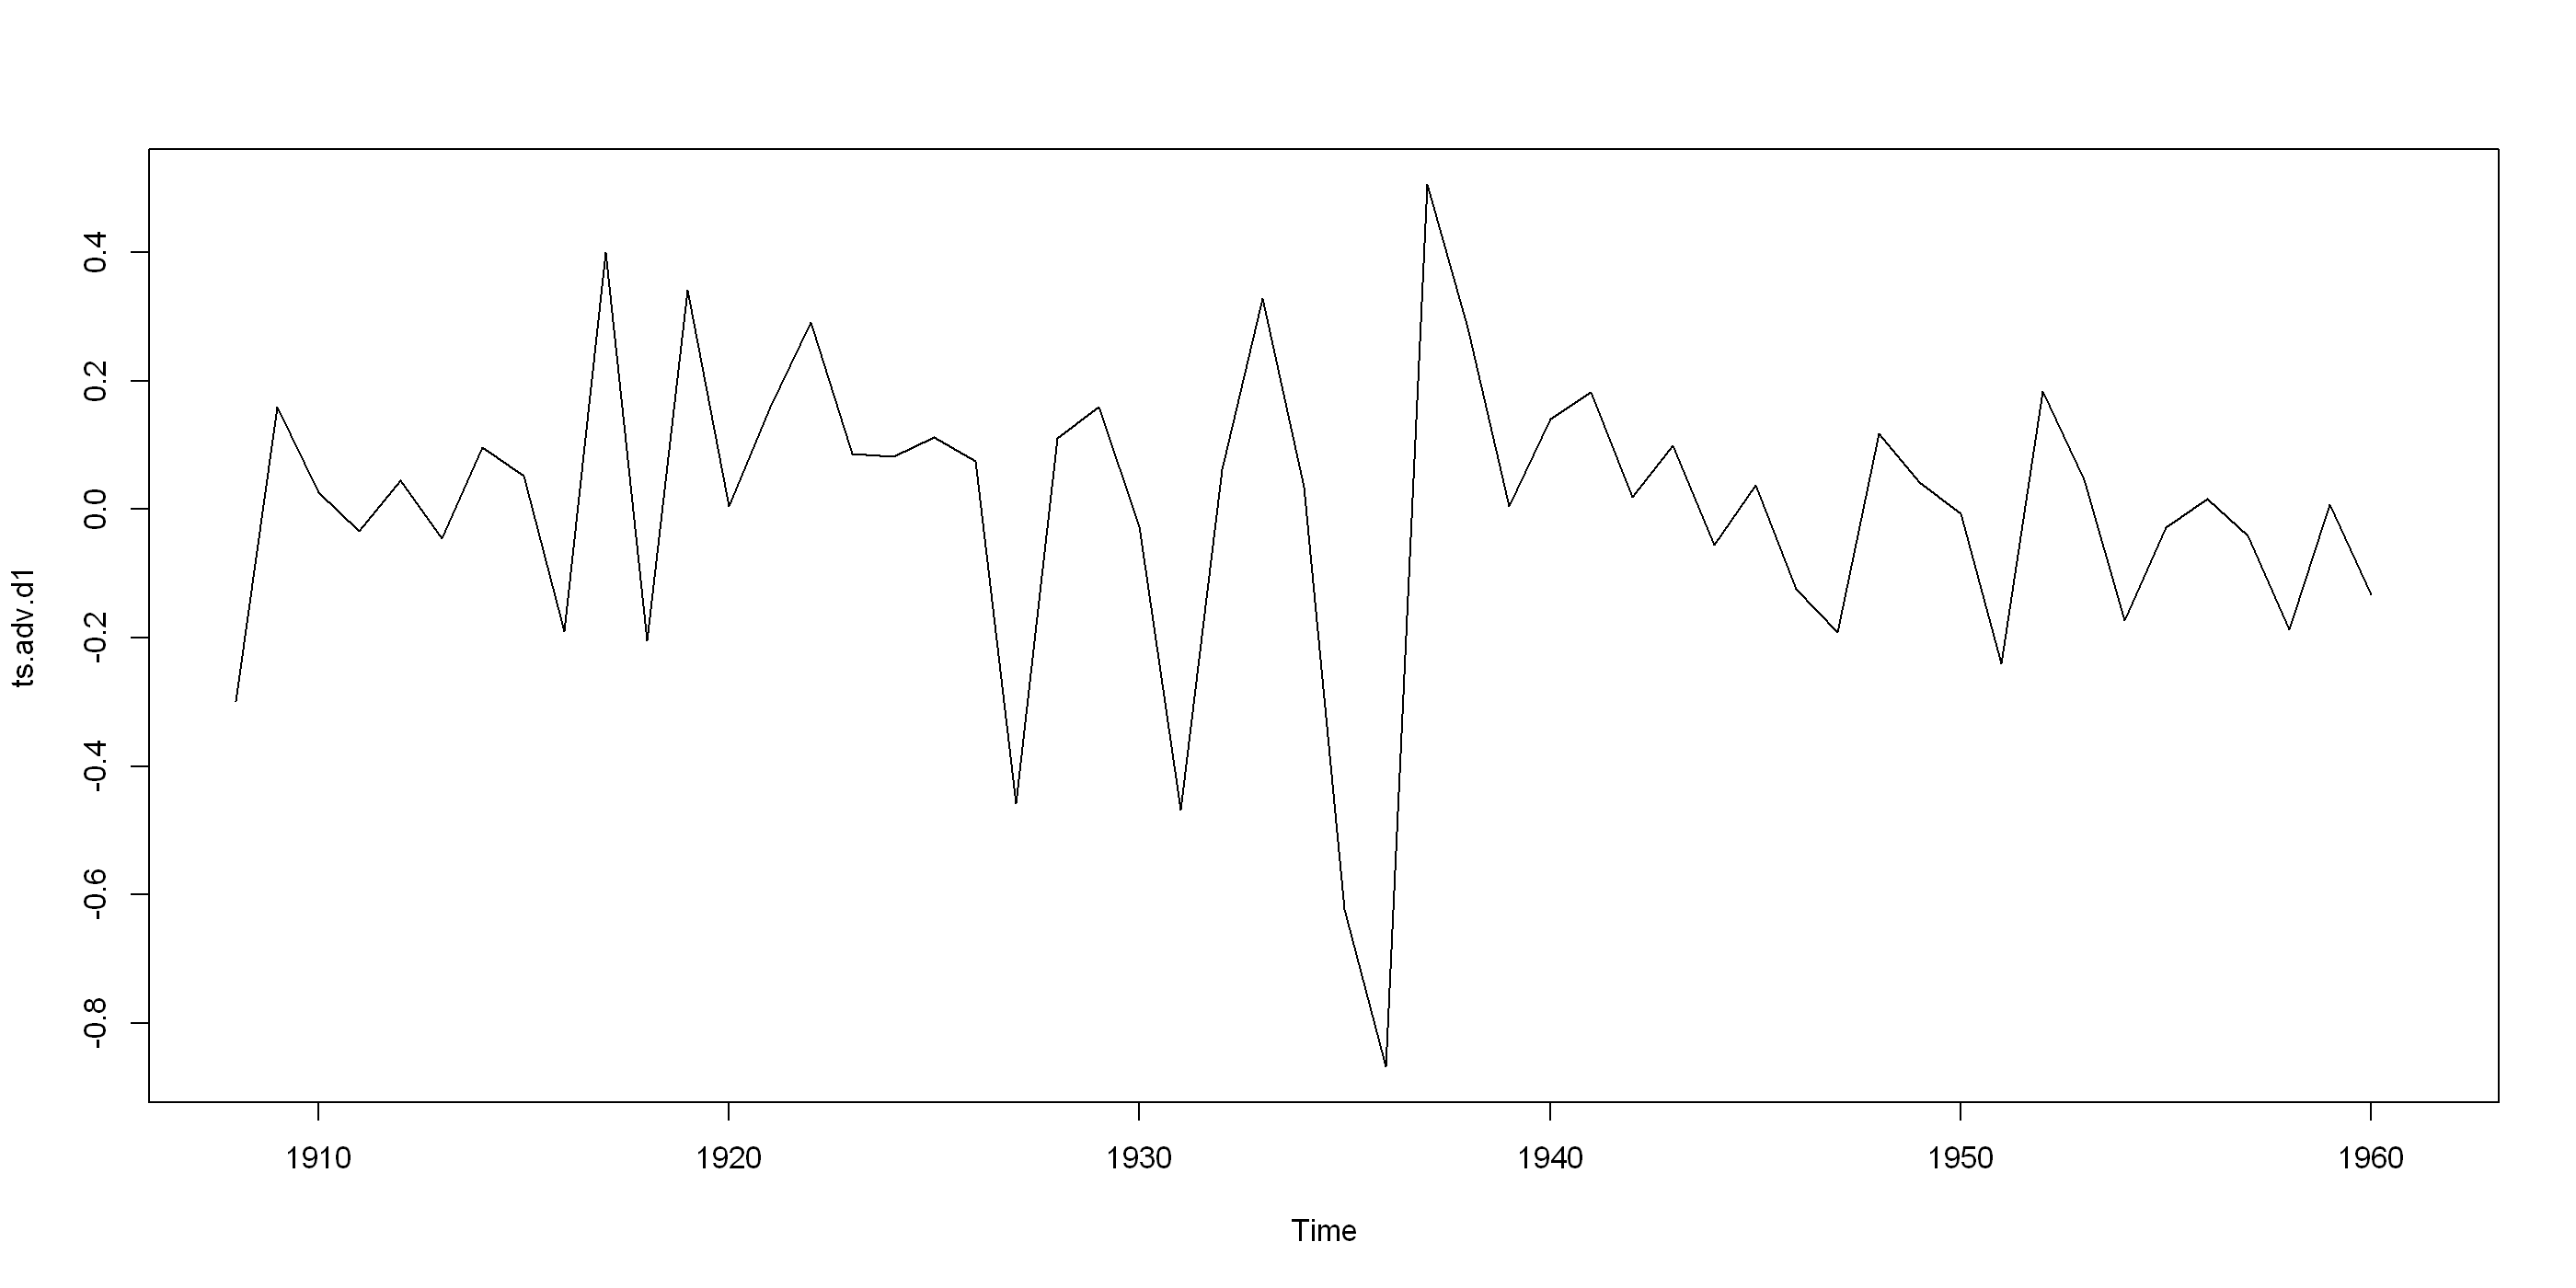

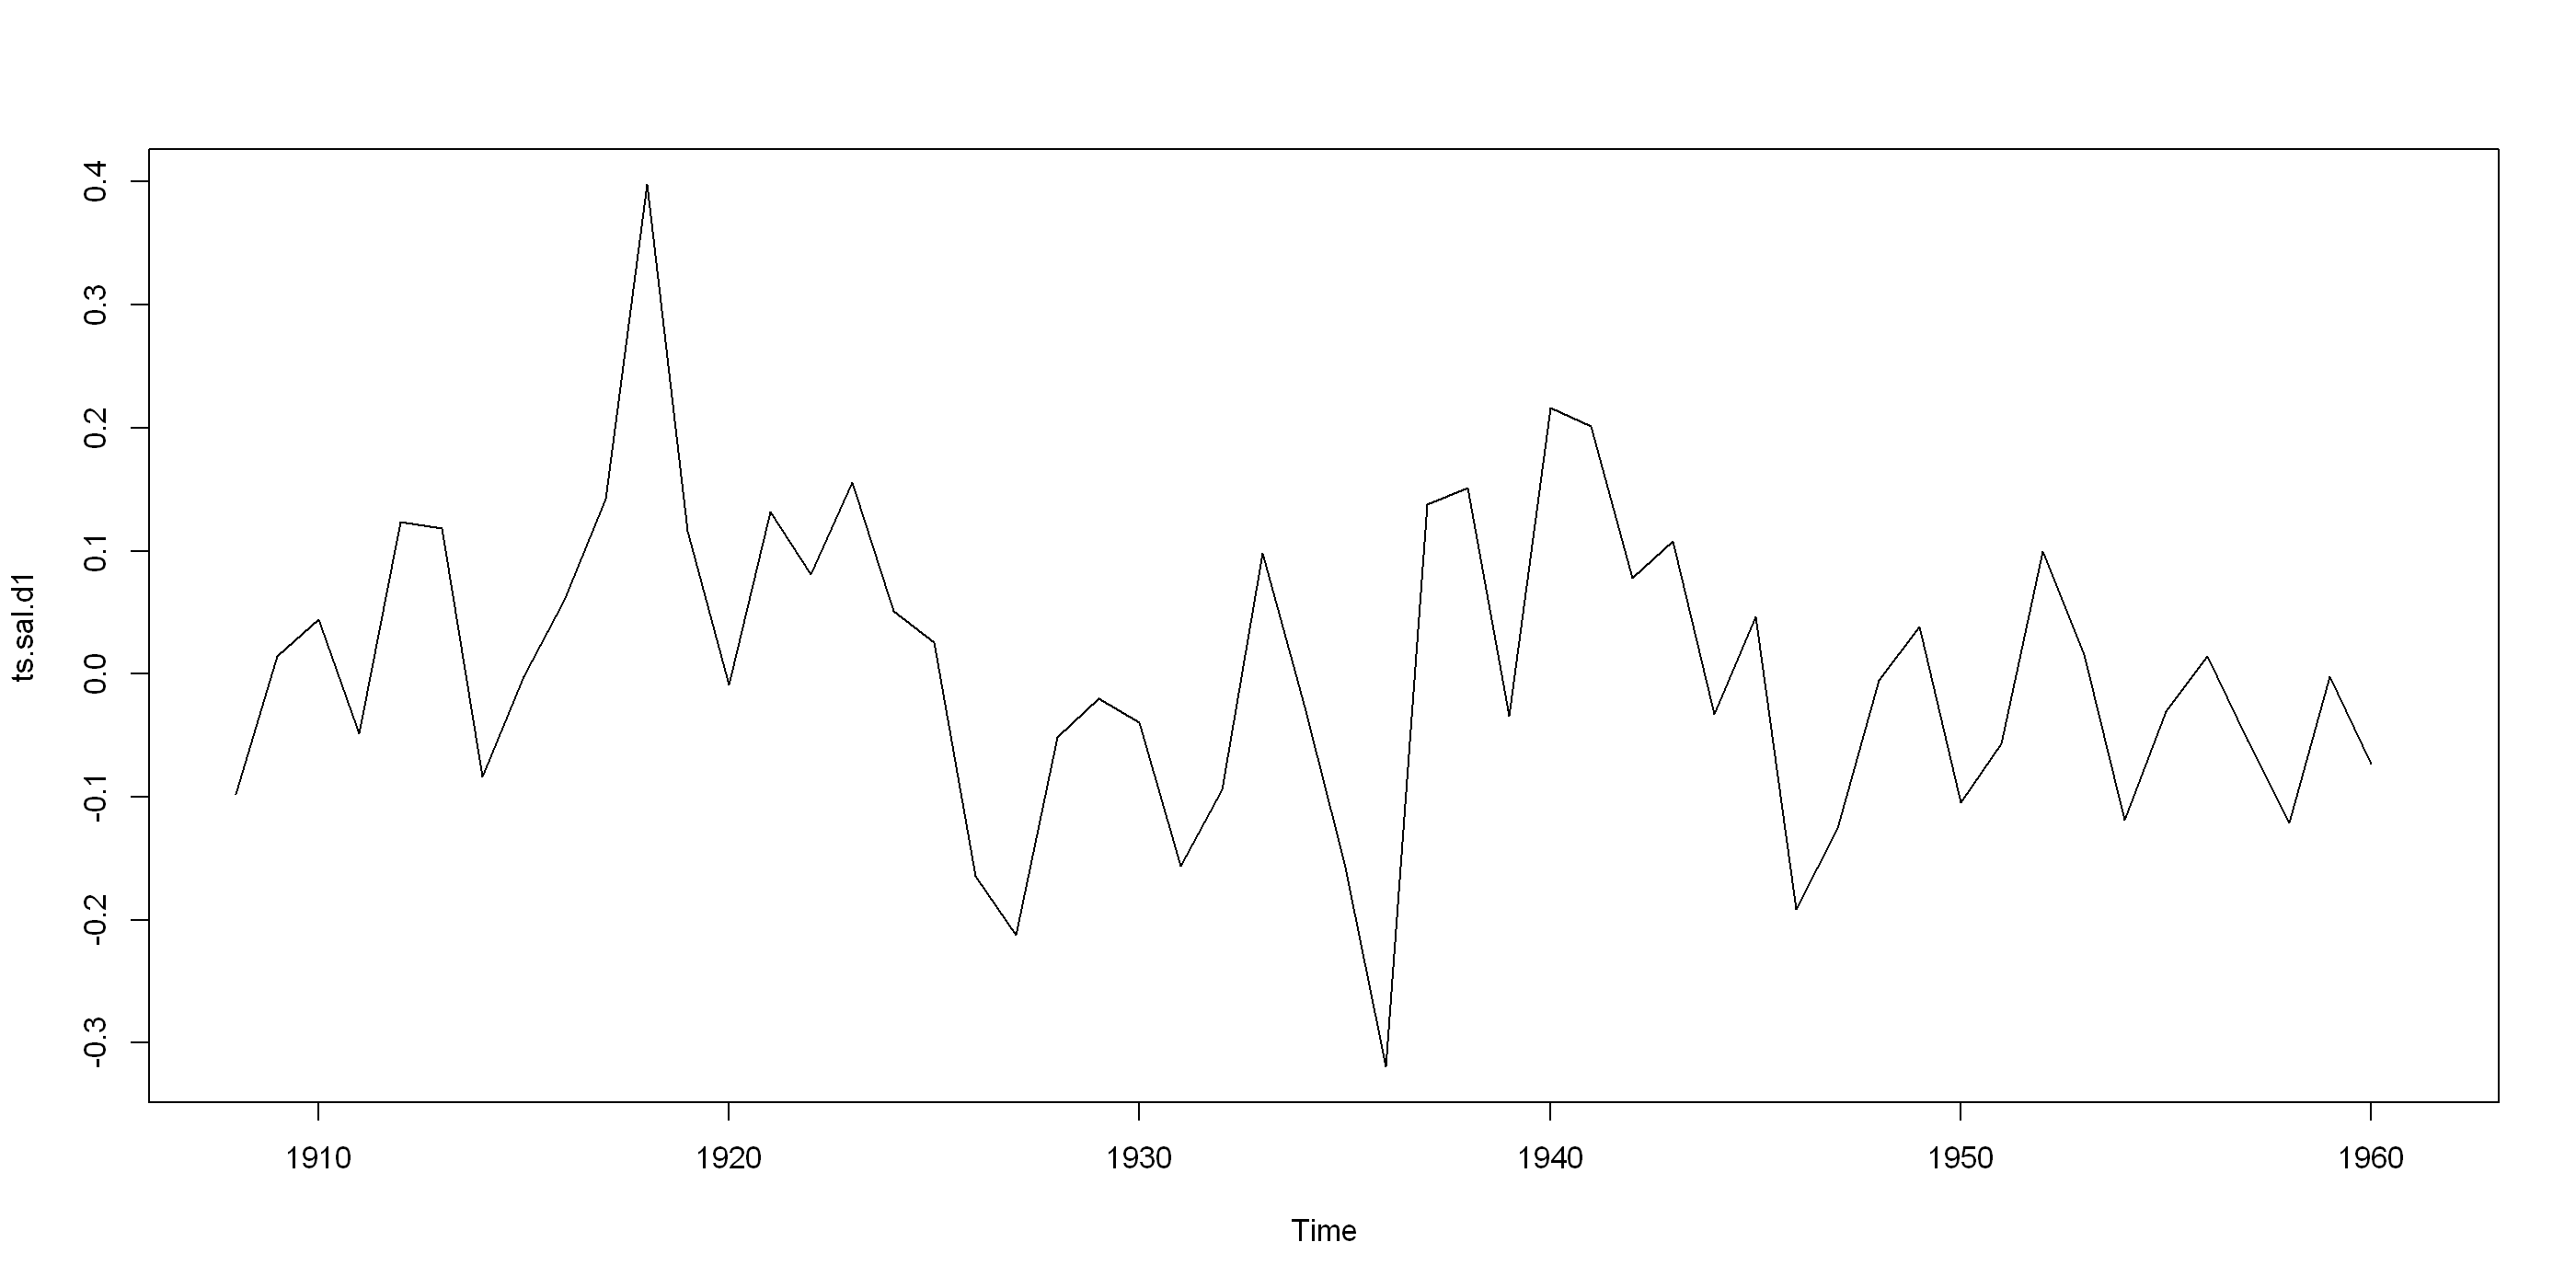

In [546]:
plot(ts.adv.d1)
plot(ts.sal.d1)

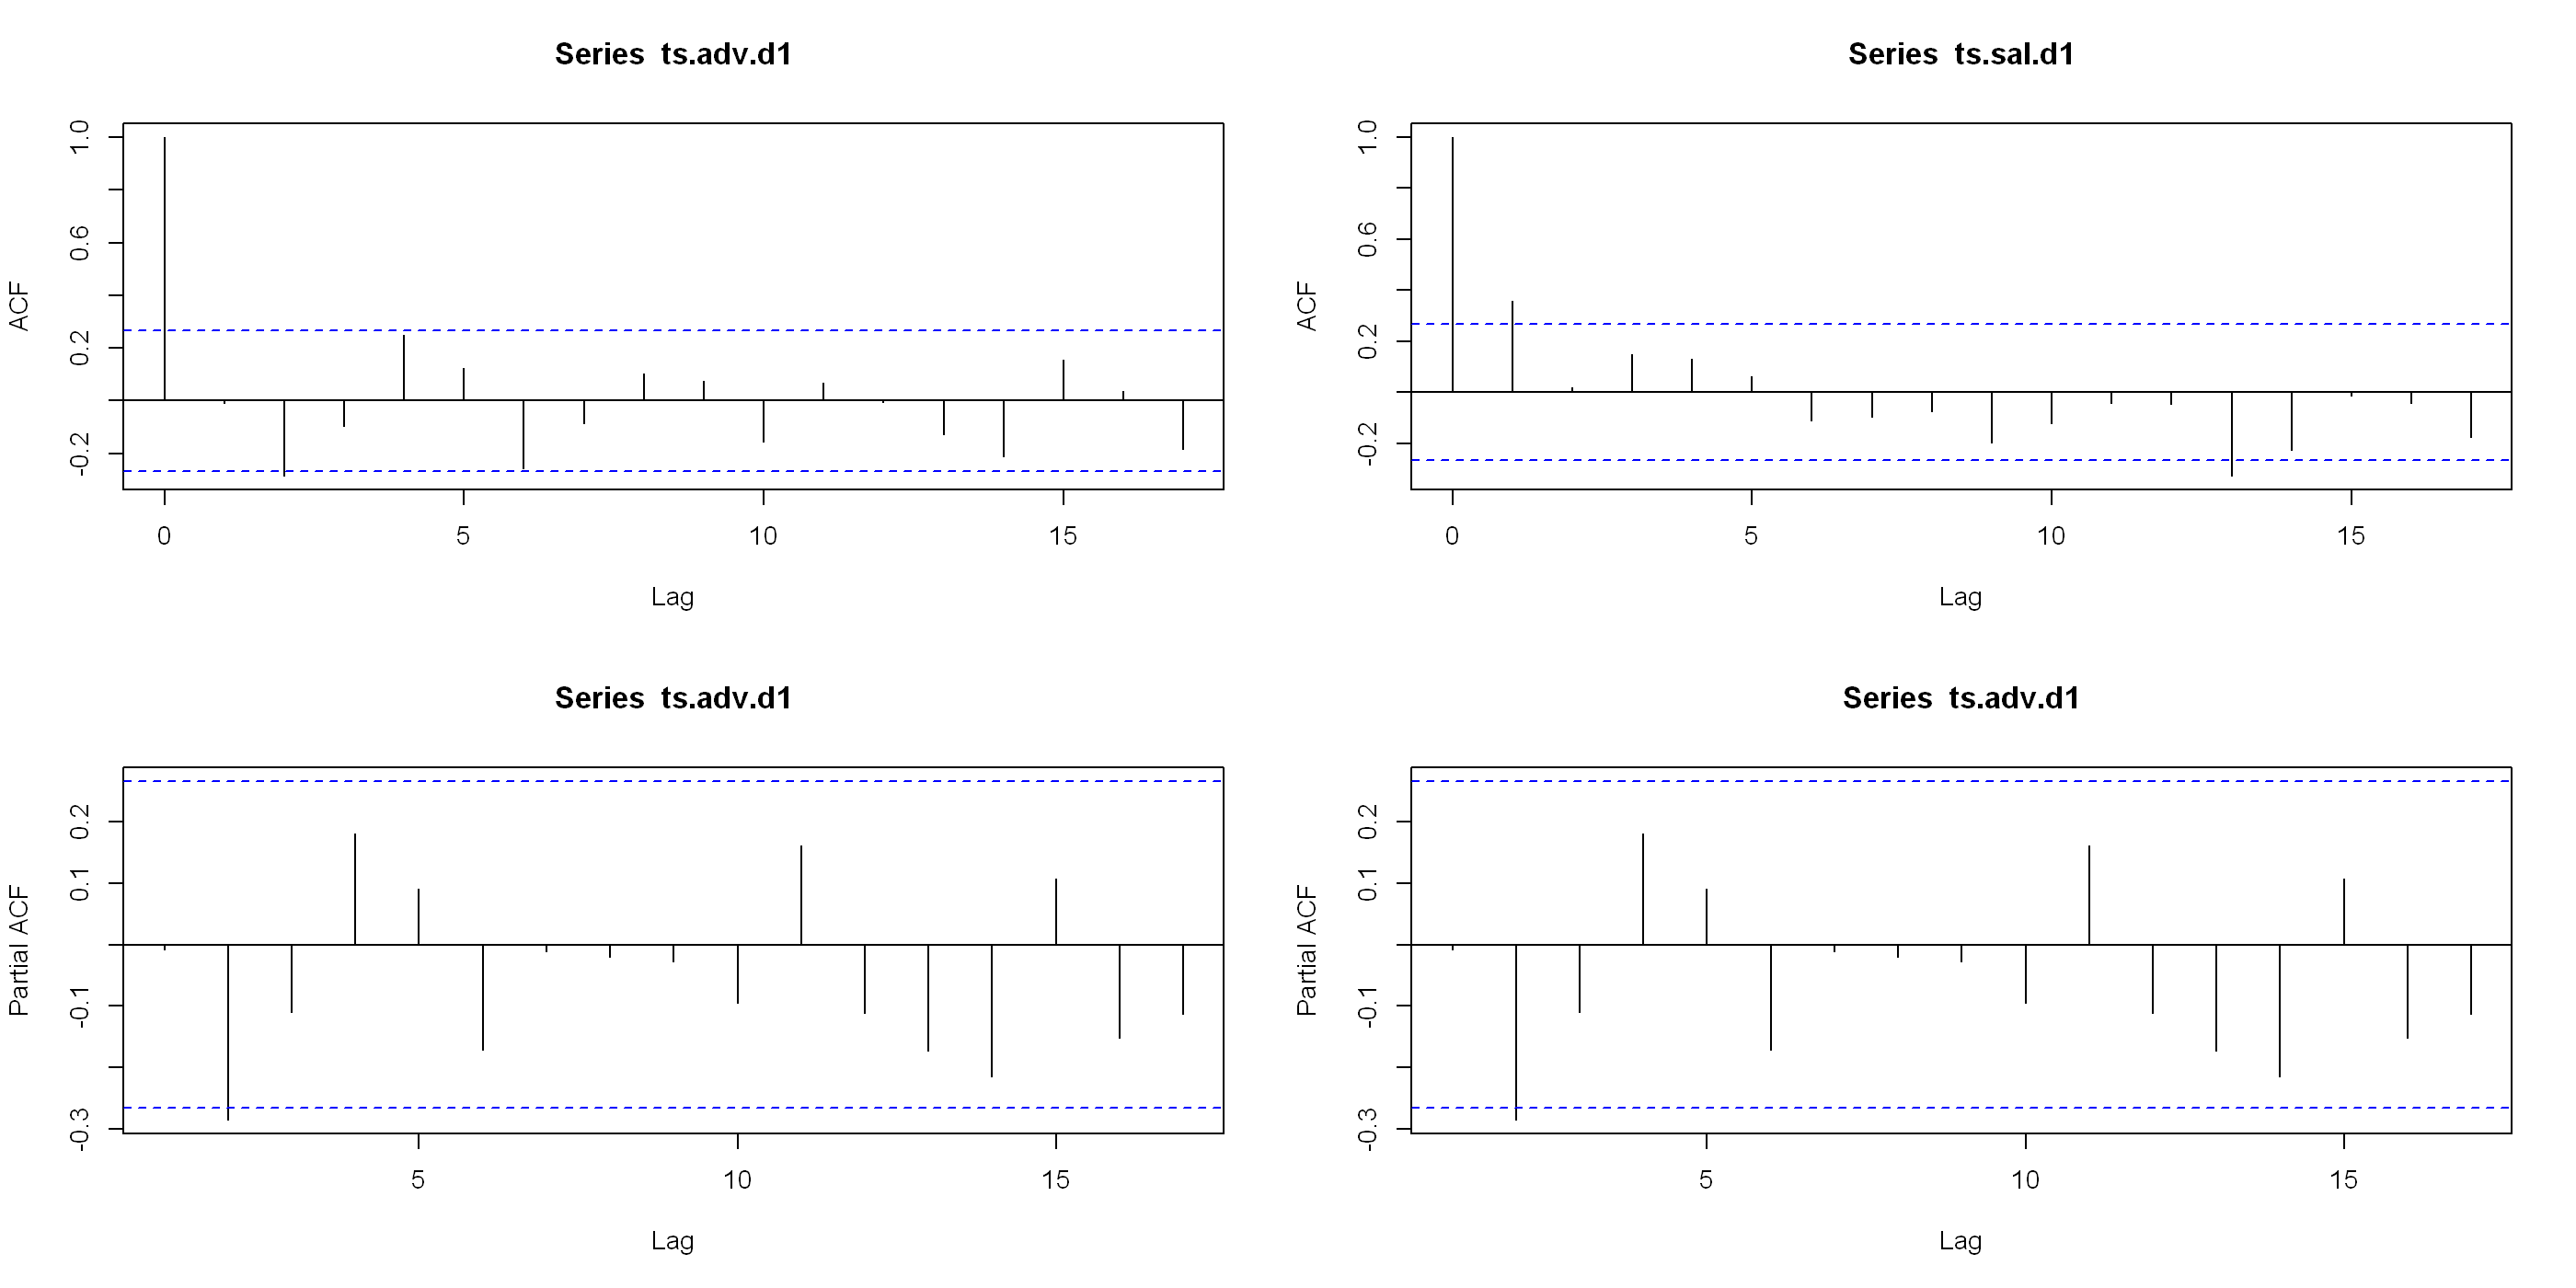

In [547]:
par(mfrow = c(2,2))
acf(ts.adv.d1,na.action = na.pass)
acf(ts.sal.d1,na.action = na.pass)
pacf(ts.adv.d1,na.action = na.pass)
pacf(ts.adv.d1,na.action = na.pass)

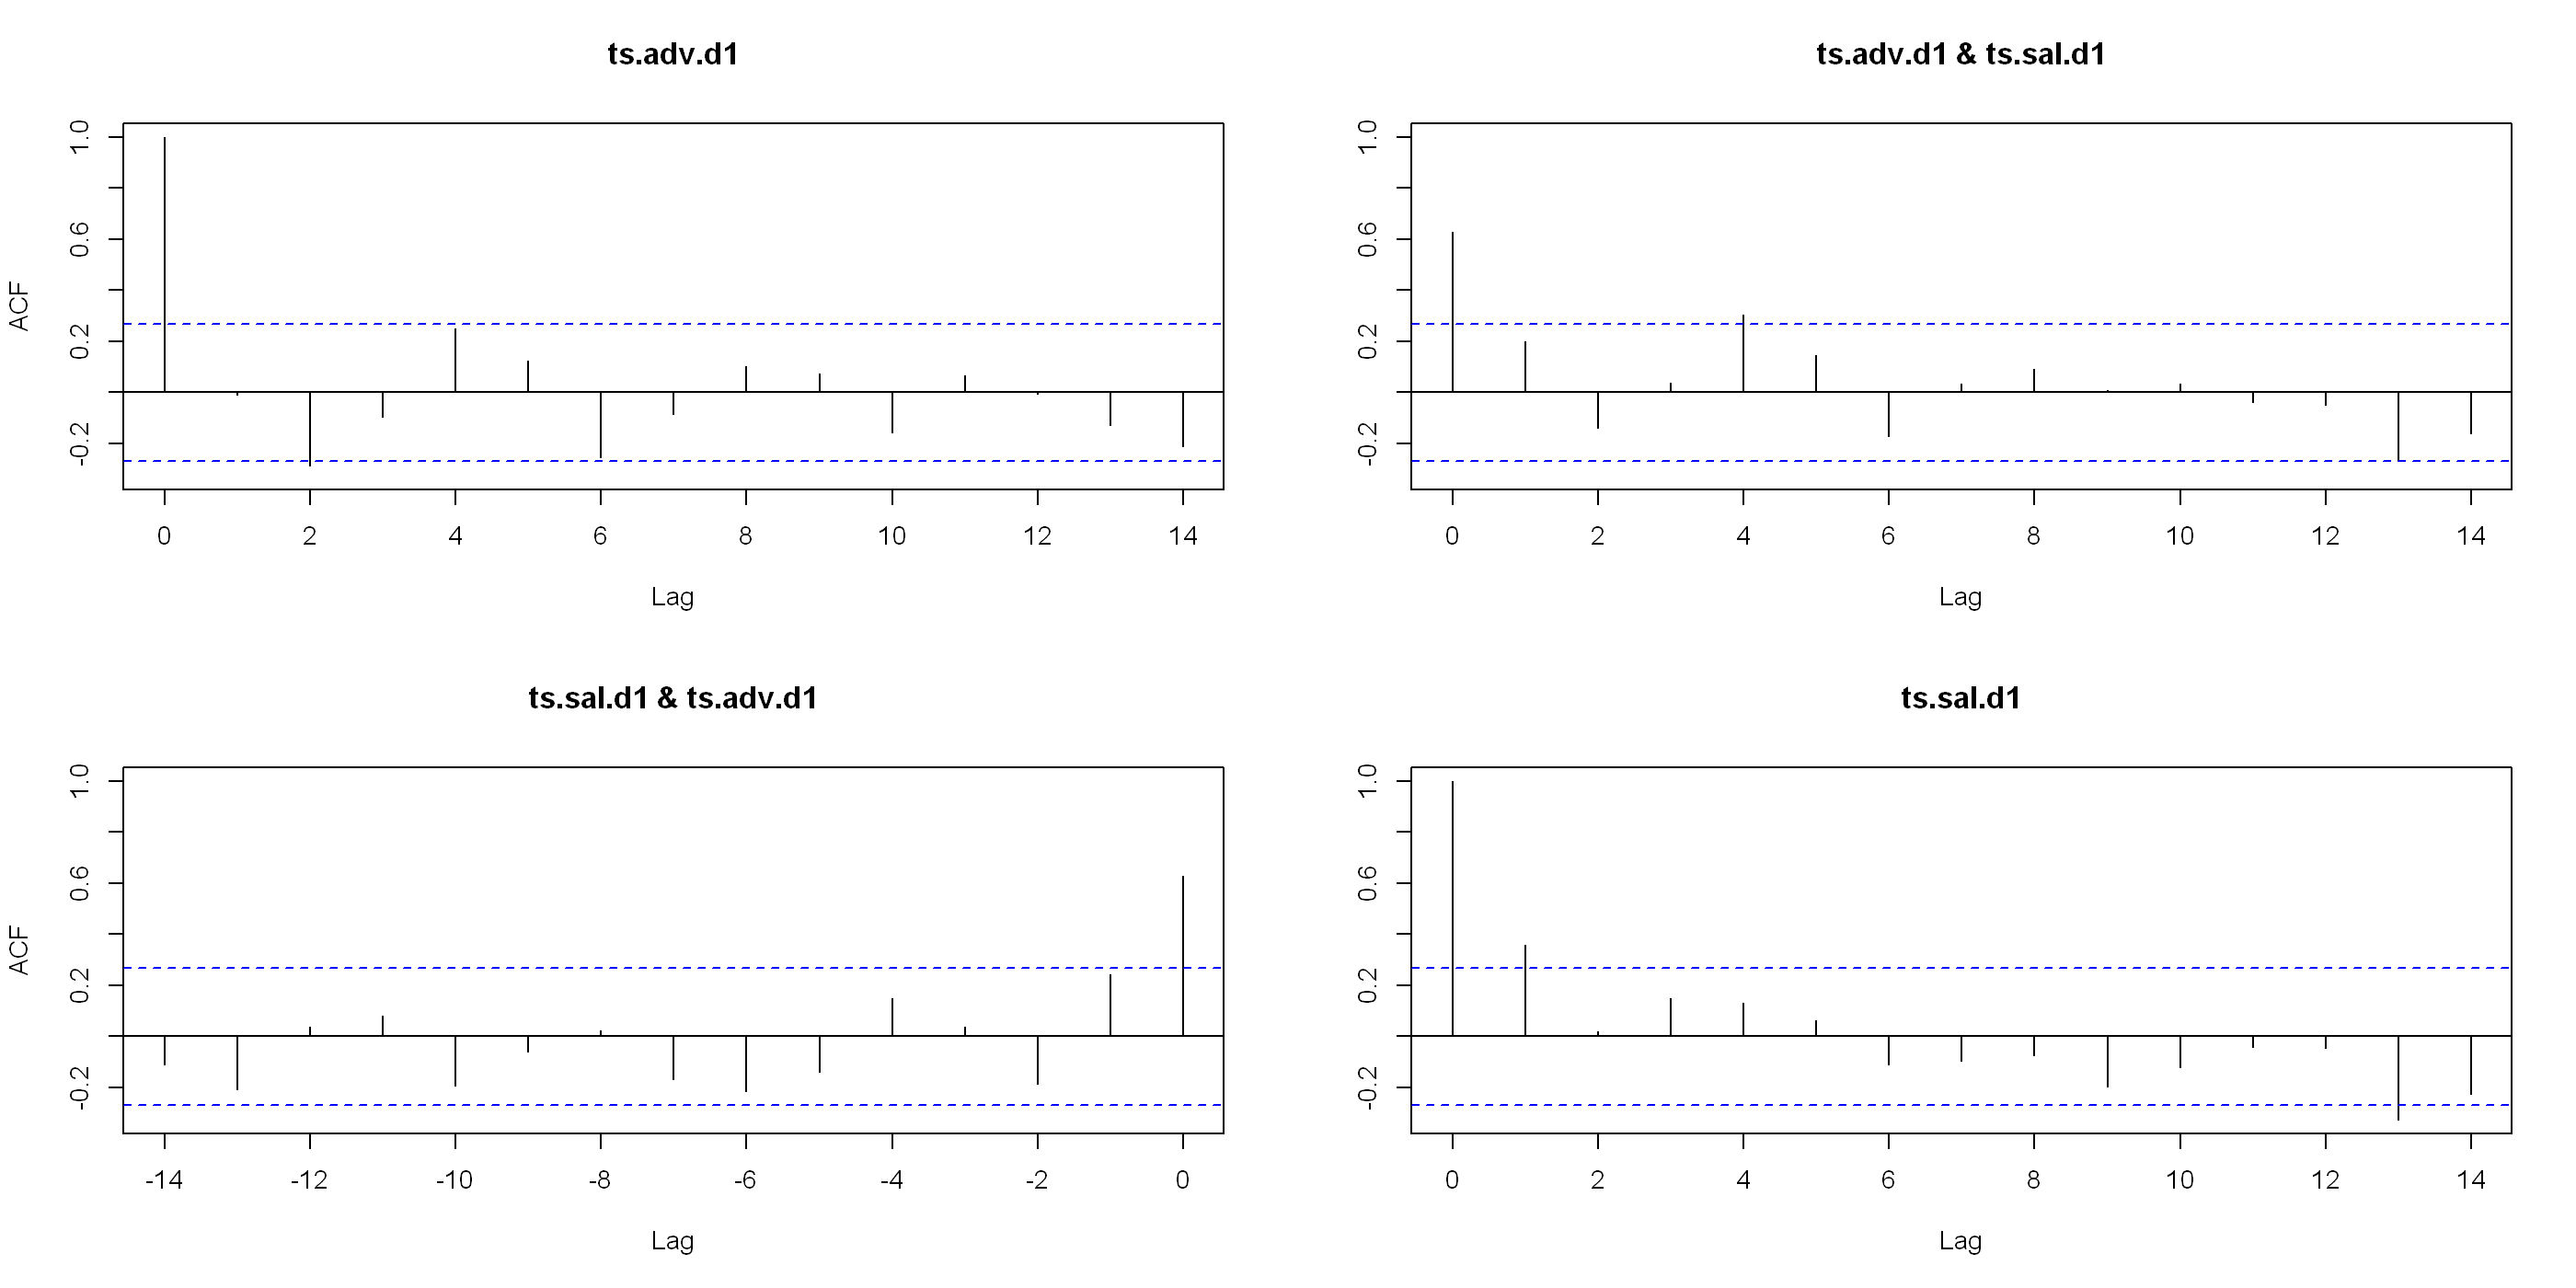

In [548]:
acf(ts.union(ts.adv.d1,ts.sal.d1),na.action = na.omit)

In [549]:
model <- arima(ts.adv.d1,order = c(2,0,0))

In [550]:
model


Call:
arima(x = ts.adv.d1, order = c(2, 0, 0))

Coefficients:
          ar1      ar2  intercept
      -0.0065  -0.2875    -0.0003
s.e.   0.1331   0.1314     0.0244

sigma^2 estimated as 0.05171:  log likelihood = 3.21,  aic = 1.59

In [551]:
model$coef[1:2]

ar1          ar2 
-0.006543172 -0.287537729

In [552]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)
par(lwd = 2, font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)

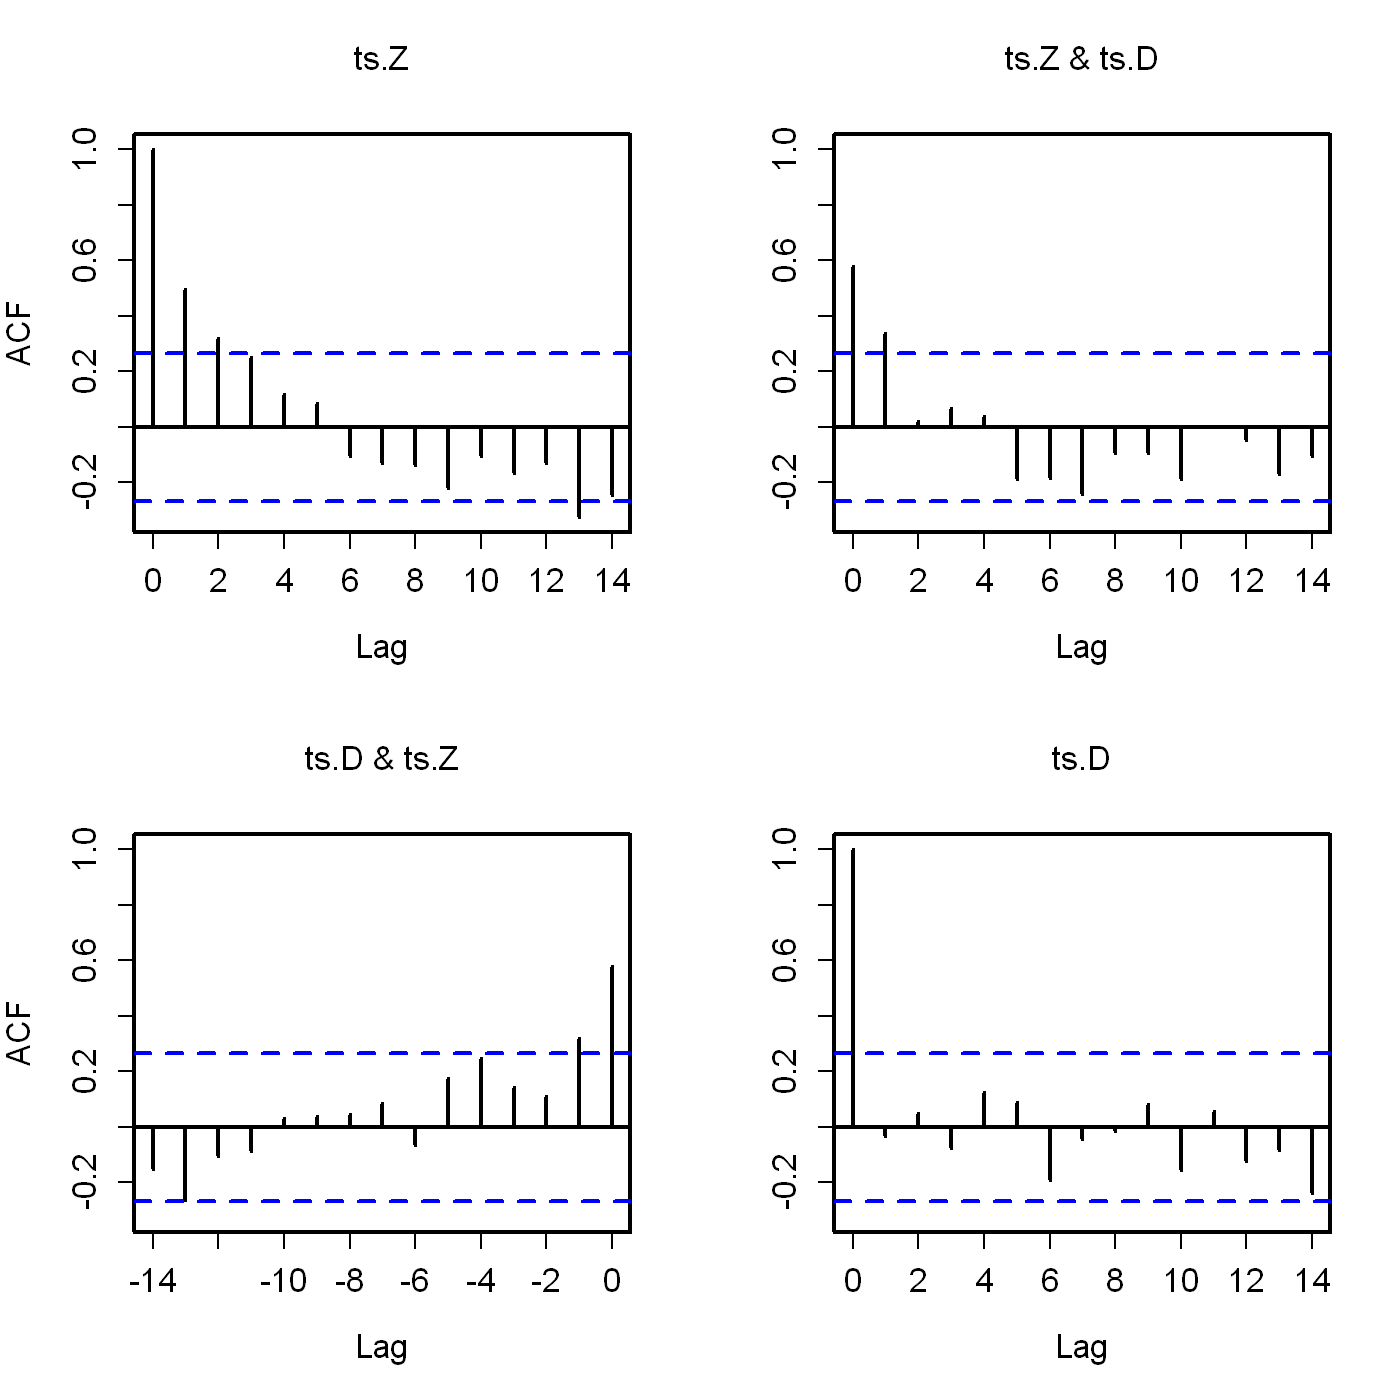

In [553]:
model <- arima(ts.adv.d1,order = c(2,0,0))
ts.D <- resid(model)
ts.Z <- filter(ts.sal.d1,c(1,-model$coef[1:2]),sides=1)
ts.trans <- ts.intersect(ts.Z, ts.D)


par(lwd = 2, font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
acf(ts.trans,na.action = na.pass)

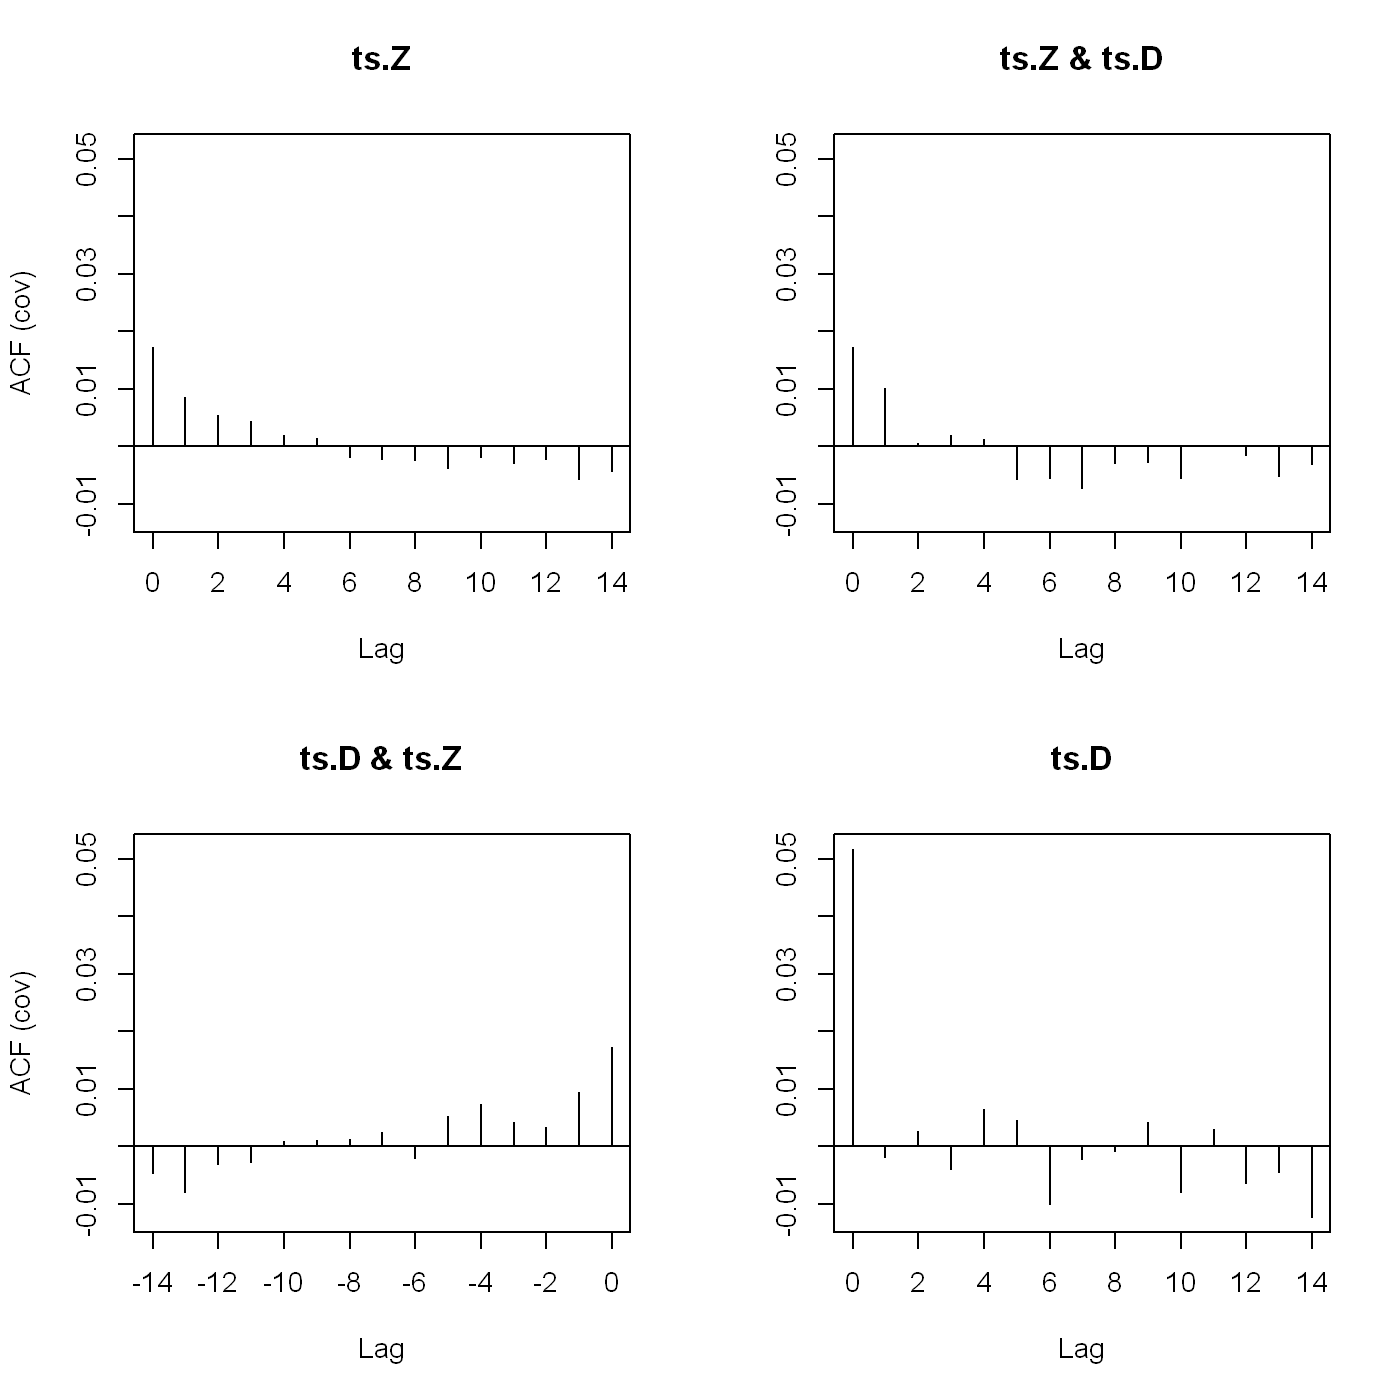

In [554]:
gamma <- acf(ts.trans,na.action = na.pass,type="covariance")

In [555]:
gamma_21 <- gamma$acf[,1,2]
gamma_110 <- gamma$acf[1,2,2]

In [556]:
nu_k <- gamma_21/gamma_110

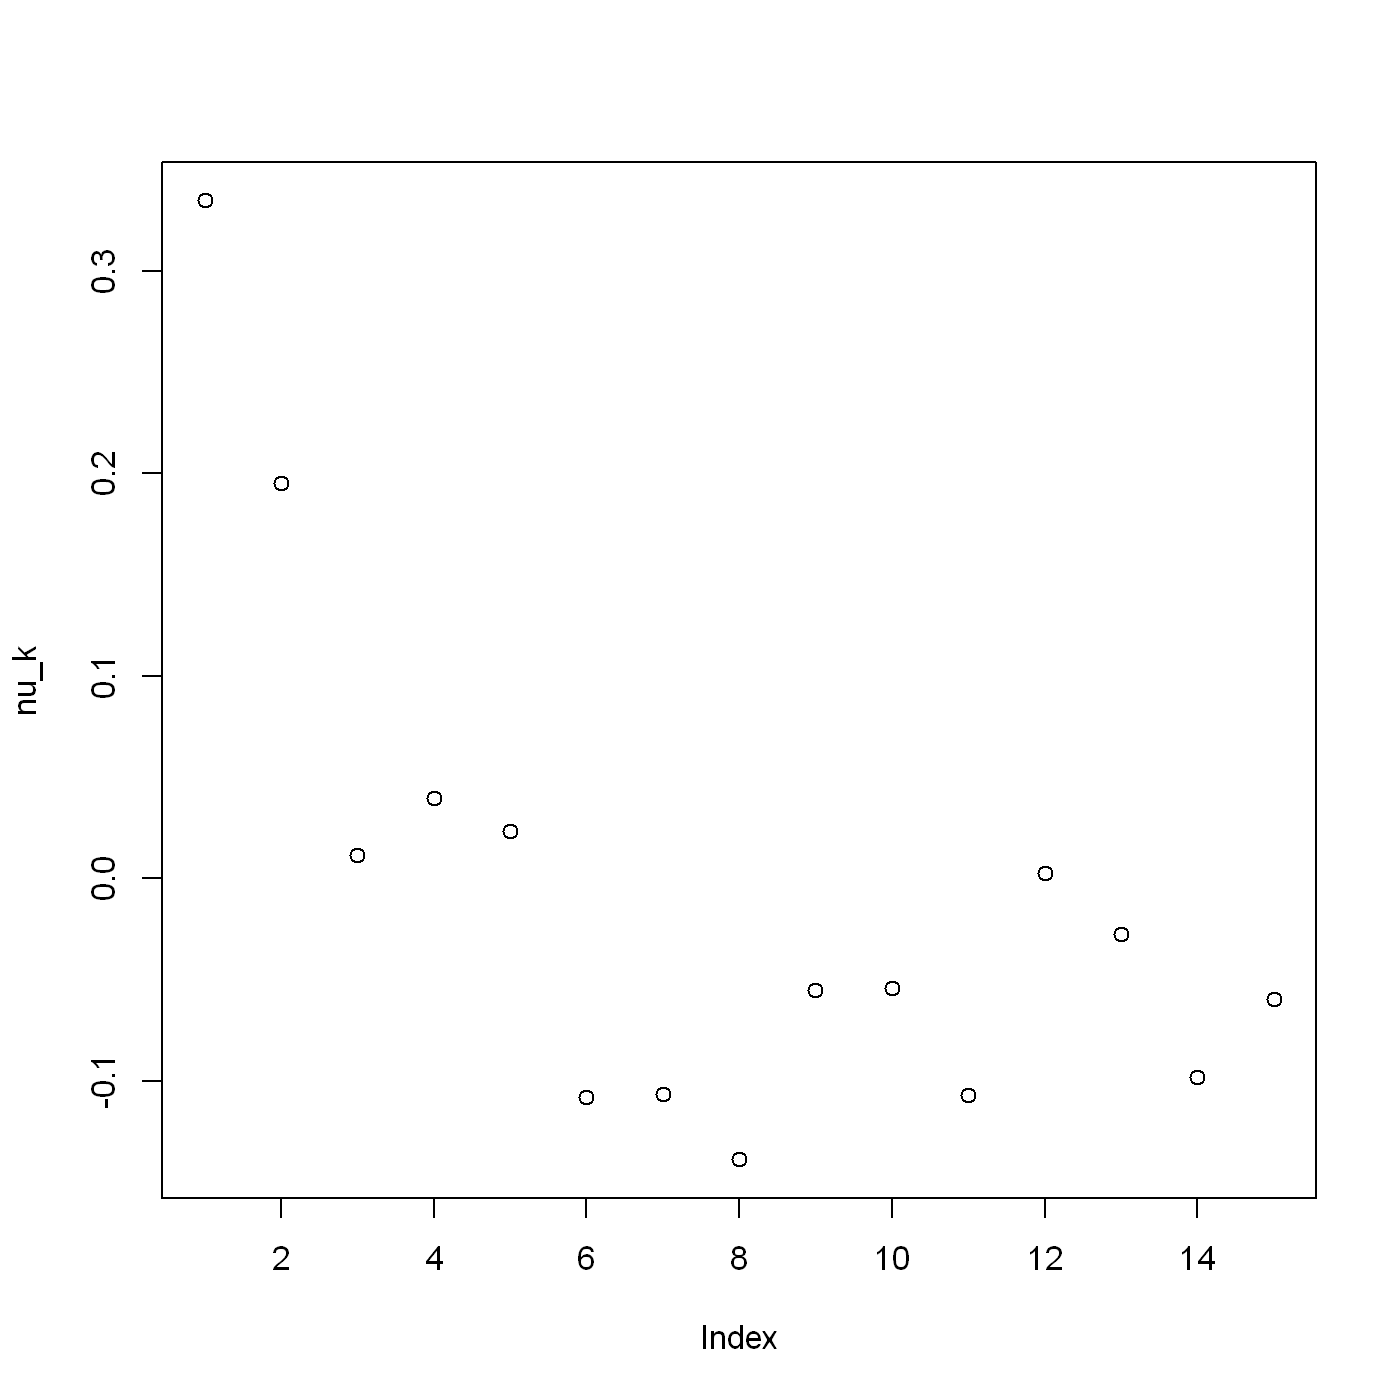

In [557]:
plot(nu_k)

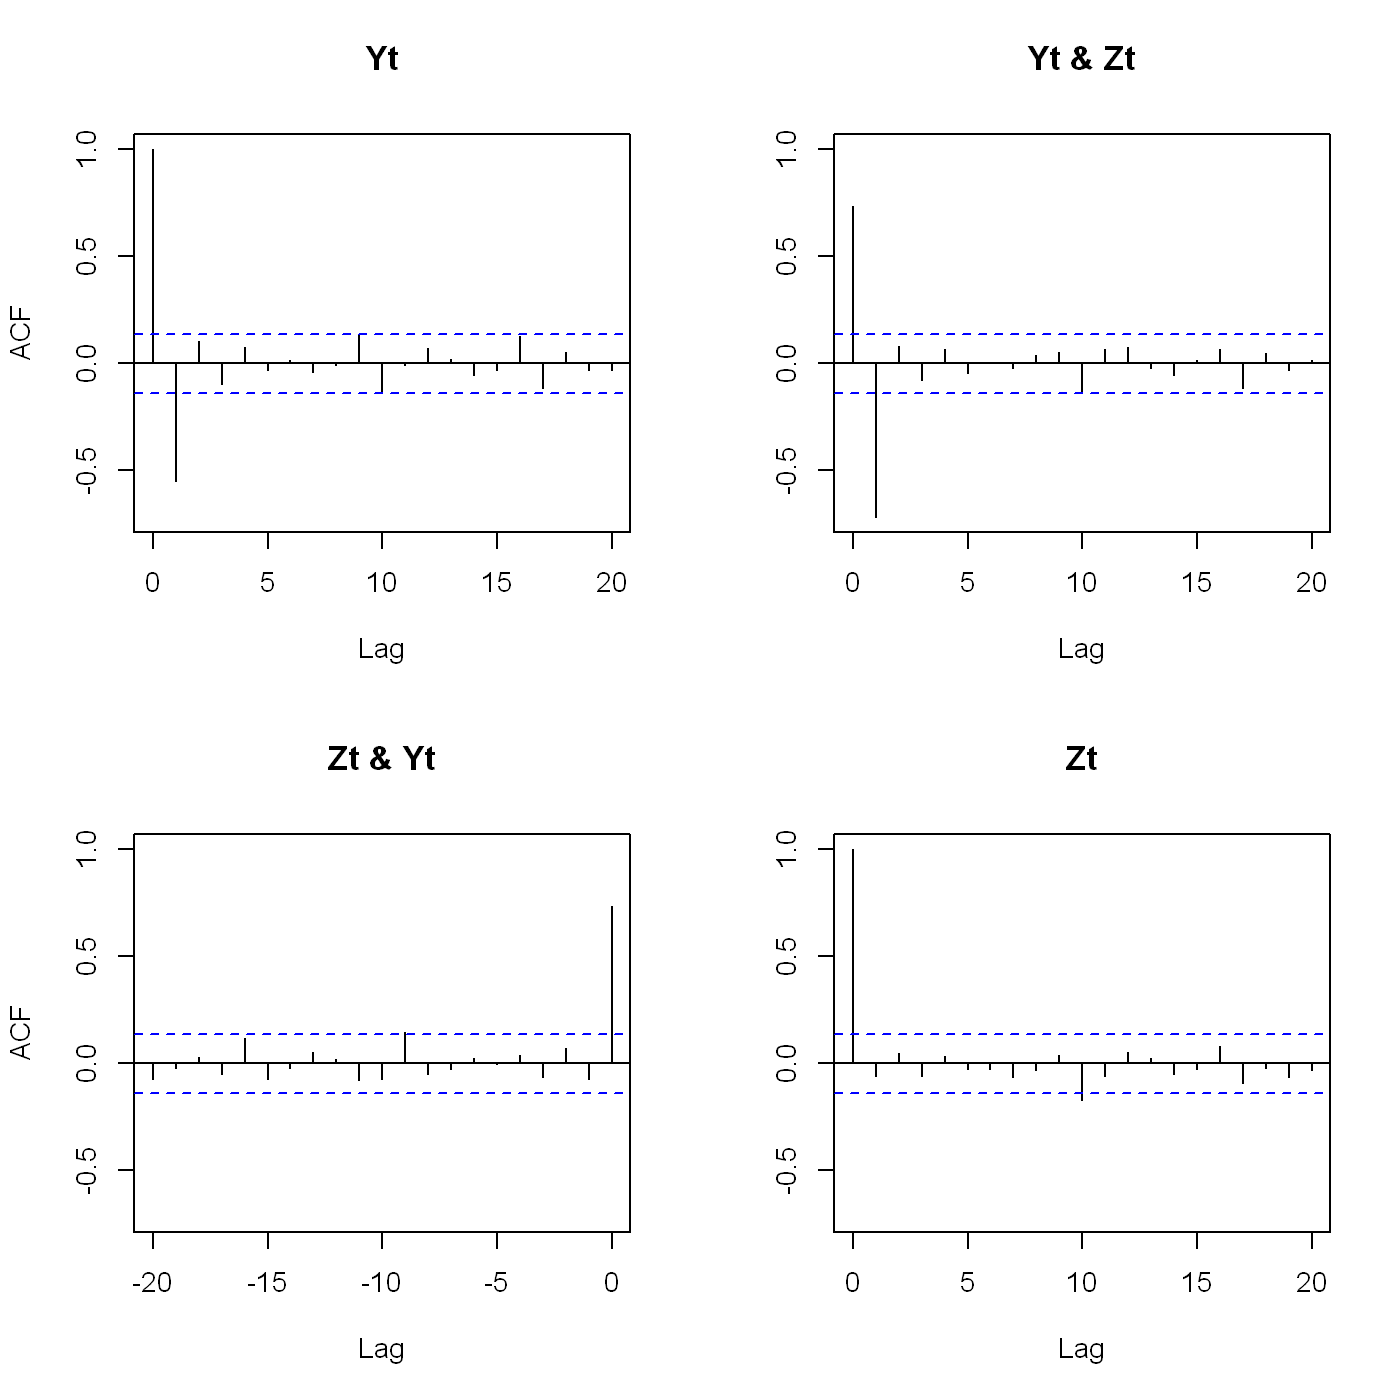

In [558]:
Et <- ts(rnorm(201))
Xt <- (1:201)+Et
Yt <- (diff(Xt))
Zt <- (Xt-(1:201))

YZ <- ts.intersect(Yt,Zt)
acf(YZ)

In [559]:
acf(YZ,na.action = na.pass,plot = F)$acf[,2,1]

[1]  0.733005899 -0.072026349  0.072674871 -0.065205935  0.039764562
 [6] -0.002494487  0.024270892 -0.024912919 -0.049252365  0.145690899
[11] -0.073866048 -0.075629389  0.020687647  0.054355388 -0.021421797
[16] -0.073503591  0.120010283 -0.049685196  0.027307226 -0.021084747
[21] -0.072235218

In [560]:
ts.ocwave <- ts(scan("http://stat.ethz.ch/Teaching/Datasets/WBL/ocwave.dat"),
start = 1, frequency = 4)

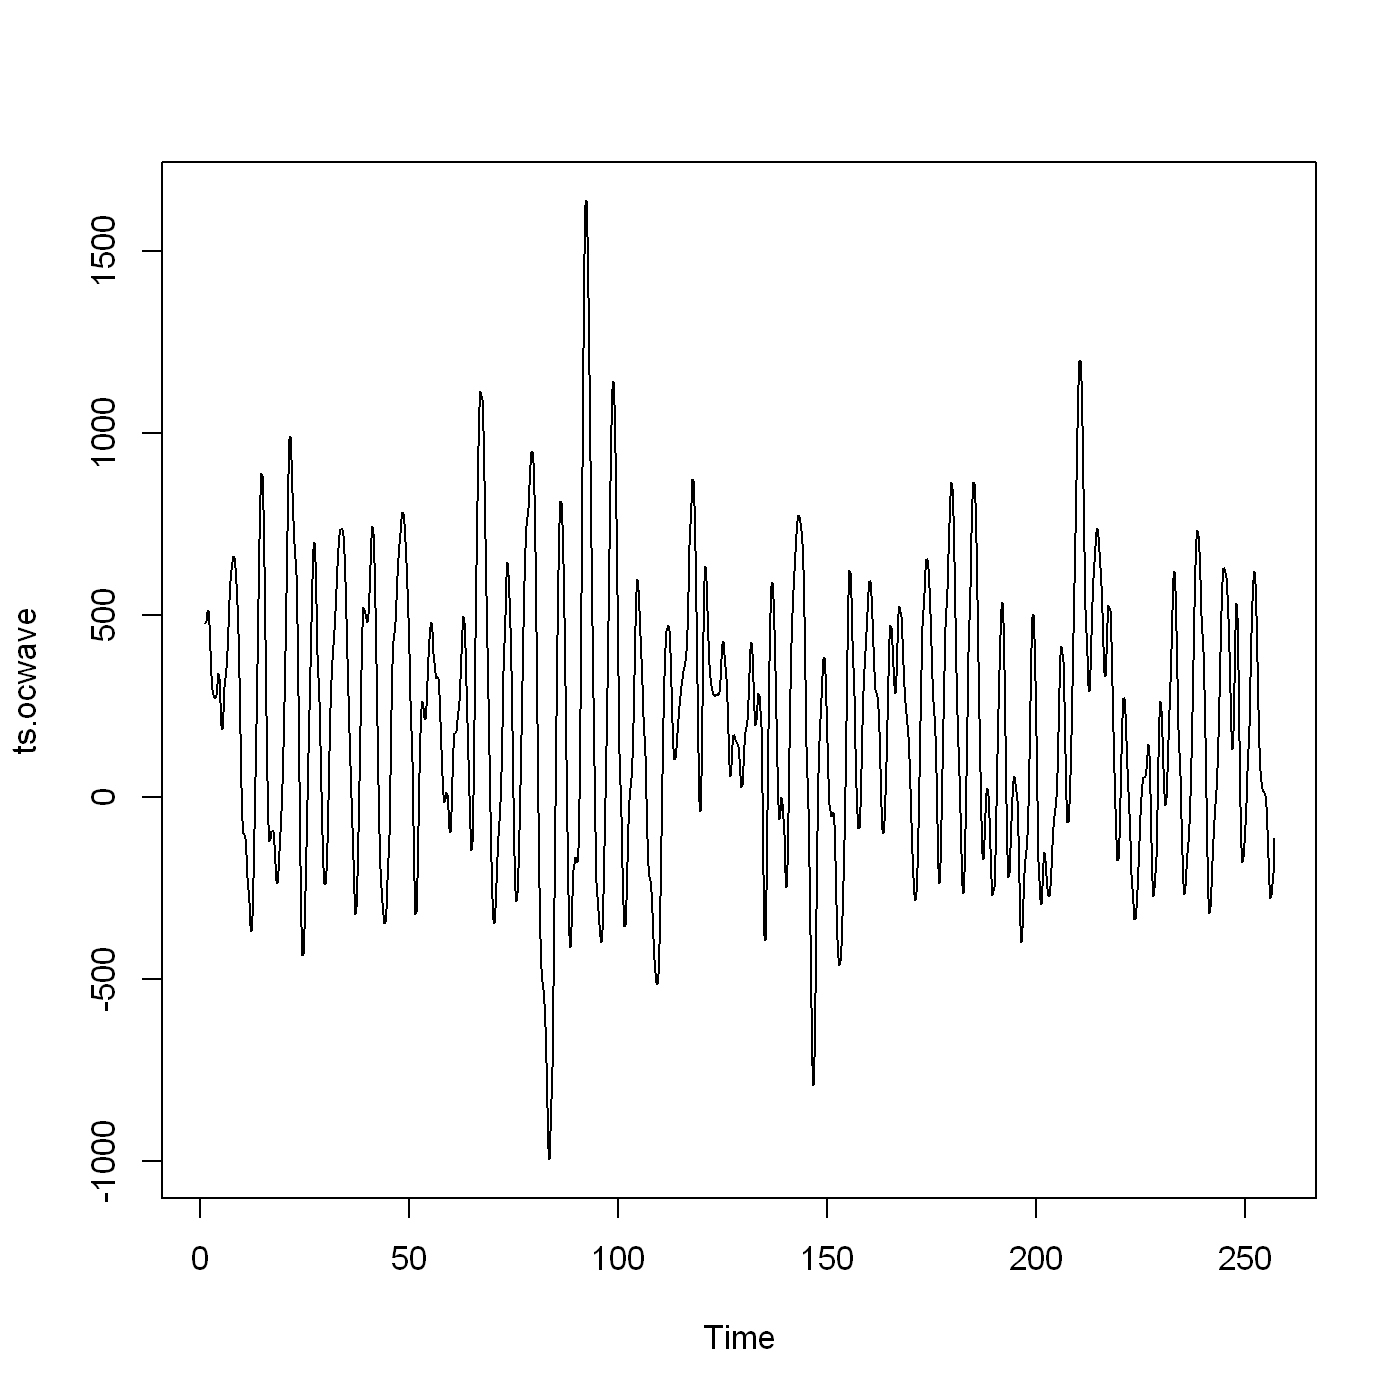

In [561]:
plot(ts.ocwave)

In [562]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)


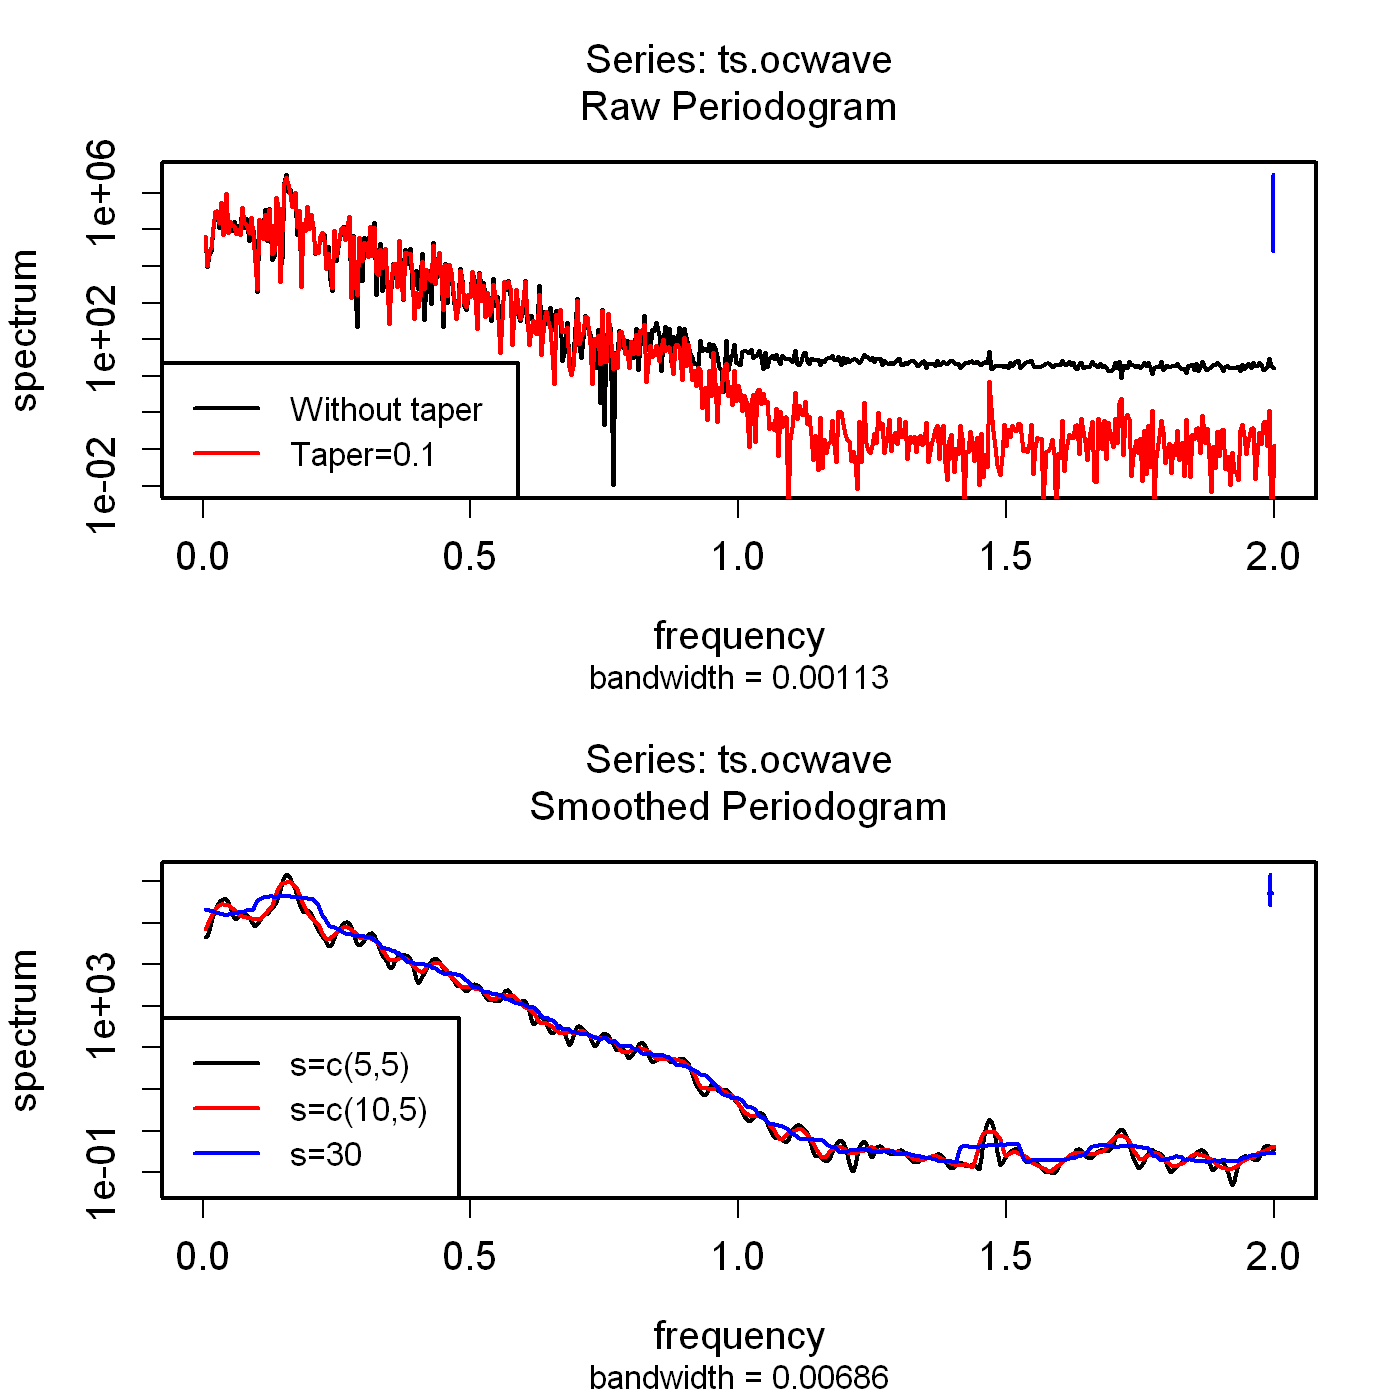

In [563]:
s <- spec.pgram(ts.ocwave, taper = F, detrend = FALSE, demean = TRUE, log = "dB",plot=F)
s2 <- spec.pgram(ts.ocwave, taper = 0.1, detrend = FALSE, demean = TRUE, log = "dB",plot=F)

par(lwd = 2,mfrow = c(2,1), font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
plot(s,lwd=2)
plot(s2,add=T,col="red",lwd=2)
legend("bottomleft",lty=c(1,1),legend = c("Without taper","Taper=0.1"),col=c("black","red"))

s3 <- spec.pgram(ts.ocwave,spans = c(5,5), taper = 0.1, detrend = FALSE, demean = TRUE, log = "dB",plot=F)
s4 <- spec.pgram(ts.ocwave,spans = c(10,5), taper = 0.1, detrend = FALSE, demean = TRUE, log = "dB",plot=F)
s5 <- spec.pgram(ts.ocwave,spans = 30, taper = 0.1, detrend = FALSE, demean = TRUE, log = "dB",plot=F)

plot(s3,lwd=2)
plot(s4,add=T,col="red",lwd=2)
plot(s5,add=T,col="blue",lwd=2)
legend("bottomleft",lty=c(1,1,1),legend = c("s=c(5,5)","s=c(10,5)","s=30"),col=c("black","red","blue"))


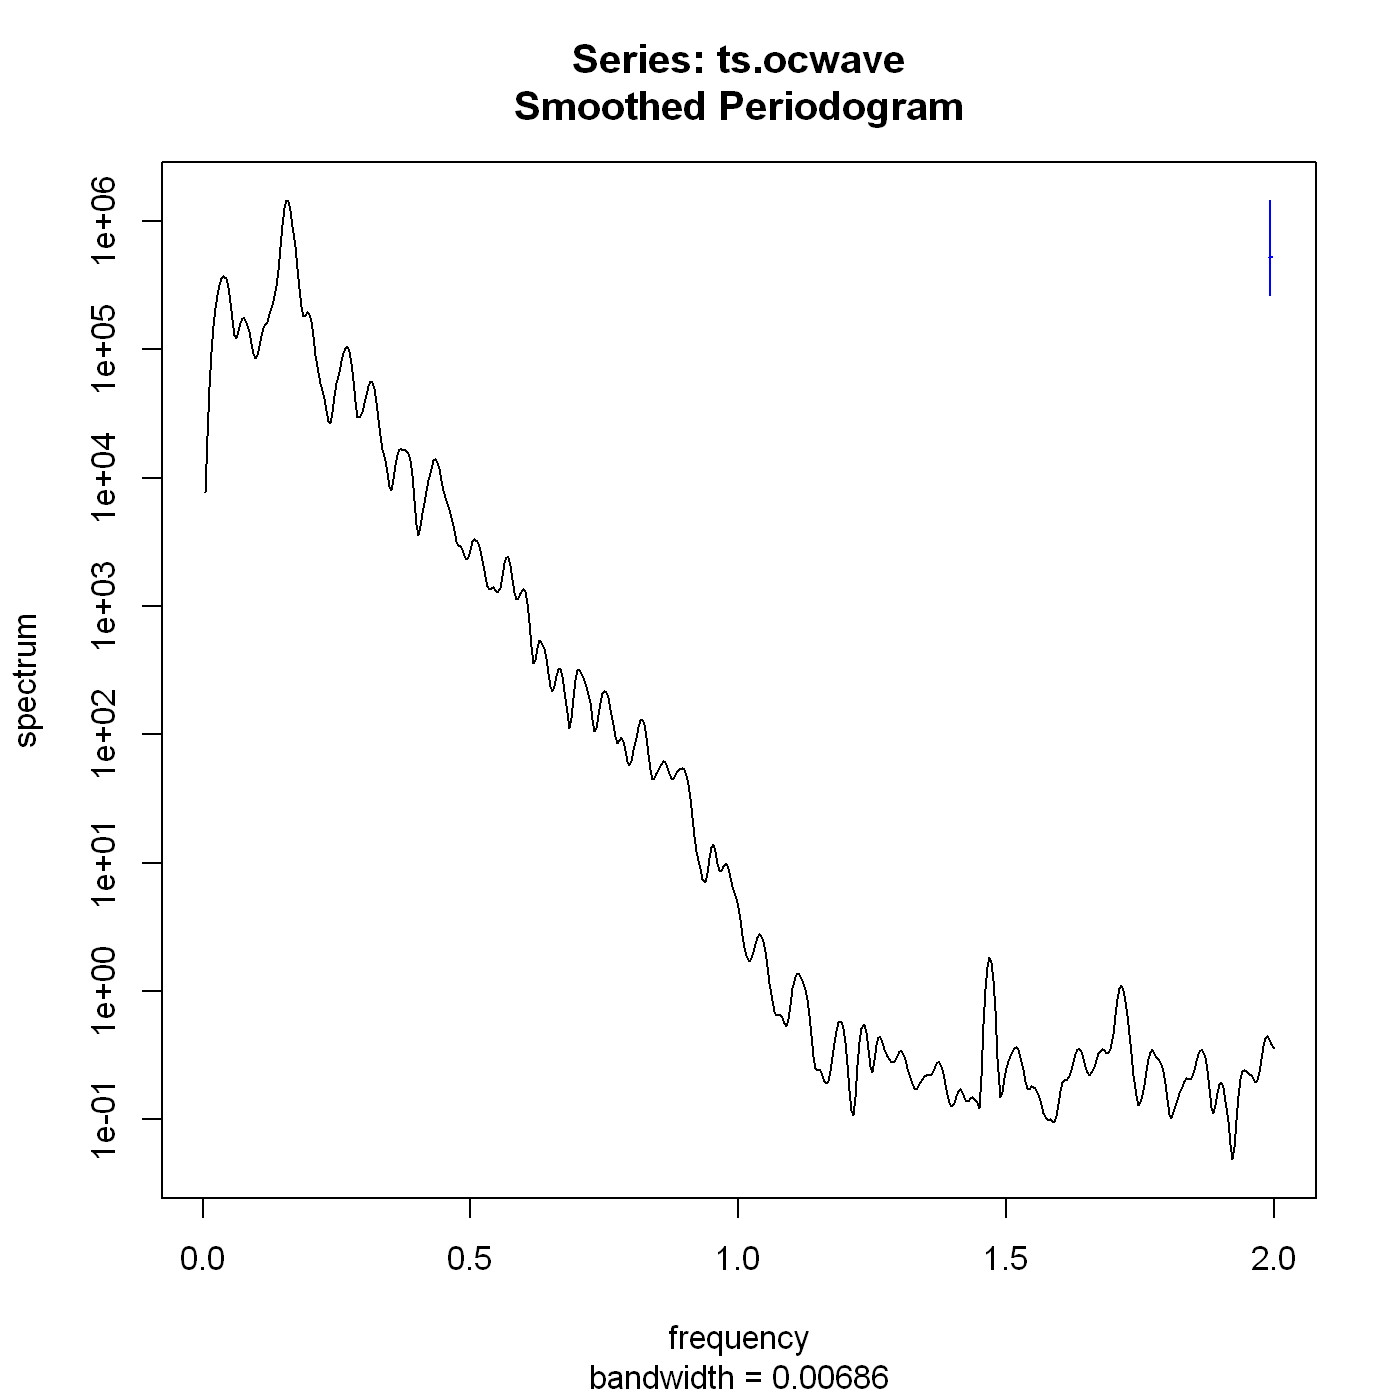

In [564]:
spec.pgram(x = ts.ocwave,spans = c(5,5))

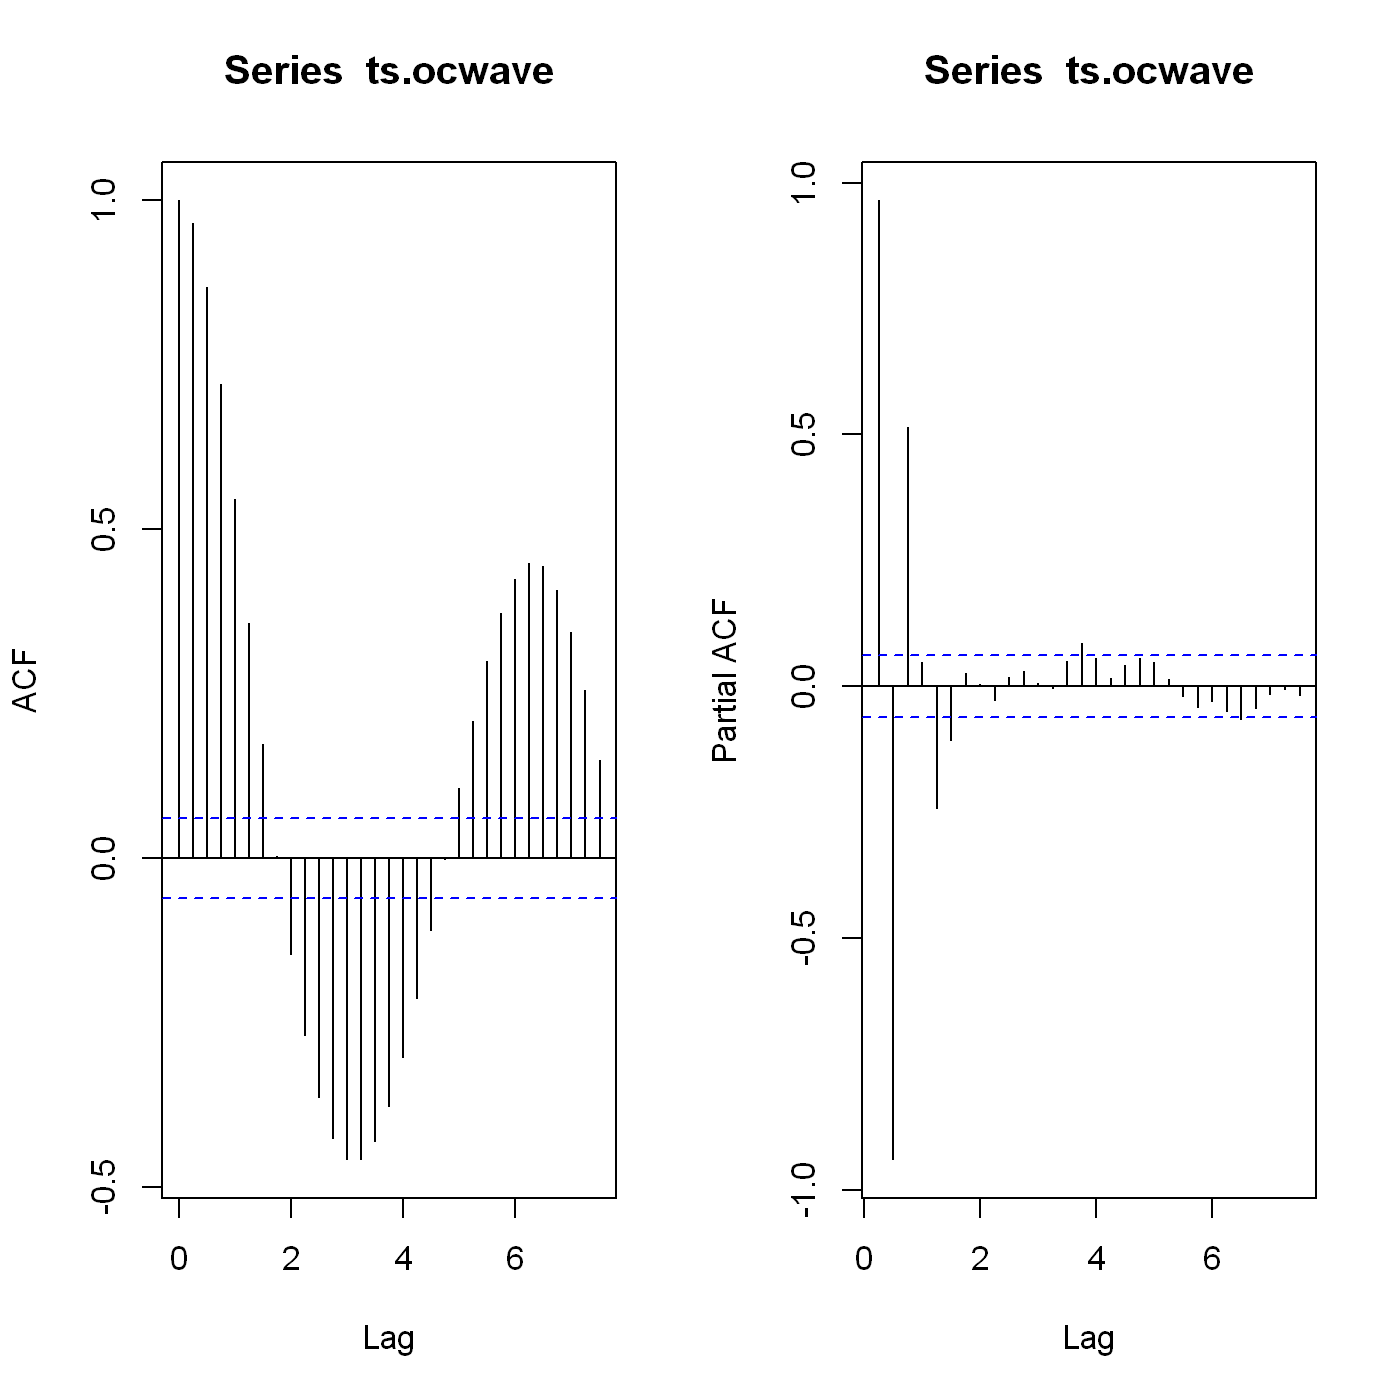

In [565]:
par(mfrow=c(1,2))
acf(ts.ocwave)
pacf(ts.ocwave)

In [566]:
ocwave.yw <- ar.yw(ts.ocwave, aic = FALSE, order = 5)
ocwave.burg <- ar.burg(ts.ocwave, aic = FALSE, order = 5)


In [567]:
ocwave.yw


Call:
ar.yw.default(x = ts.ocwave, aic = FALSE, order.max = 5)

Coefficients:
      1        2        3        4        5  
 2.3415  -1.7129  -0.0375   0.6122  -0.2421  

Order selected 5  sigma^2 estimated as  805.7

In [568]:
ocwave.burg


Call:
ar.burg.default(x = ts.ocwave, aic = FALSE, order.max = 5)

Coefficients:
      1        2        3        4        5  
 3.4194  -4.9926   3.9268  -1.6671   0.2967  

Order selected 5  sigma^2 estimated as  149.7

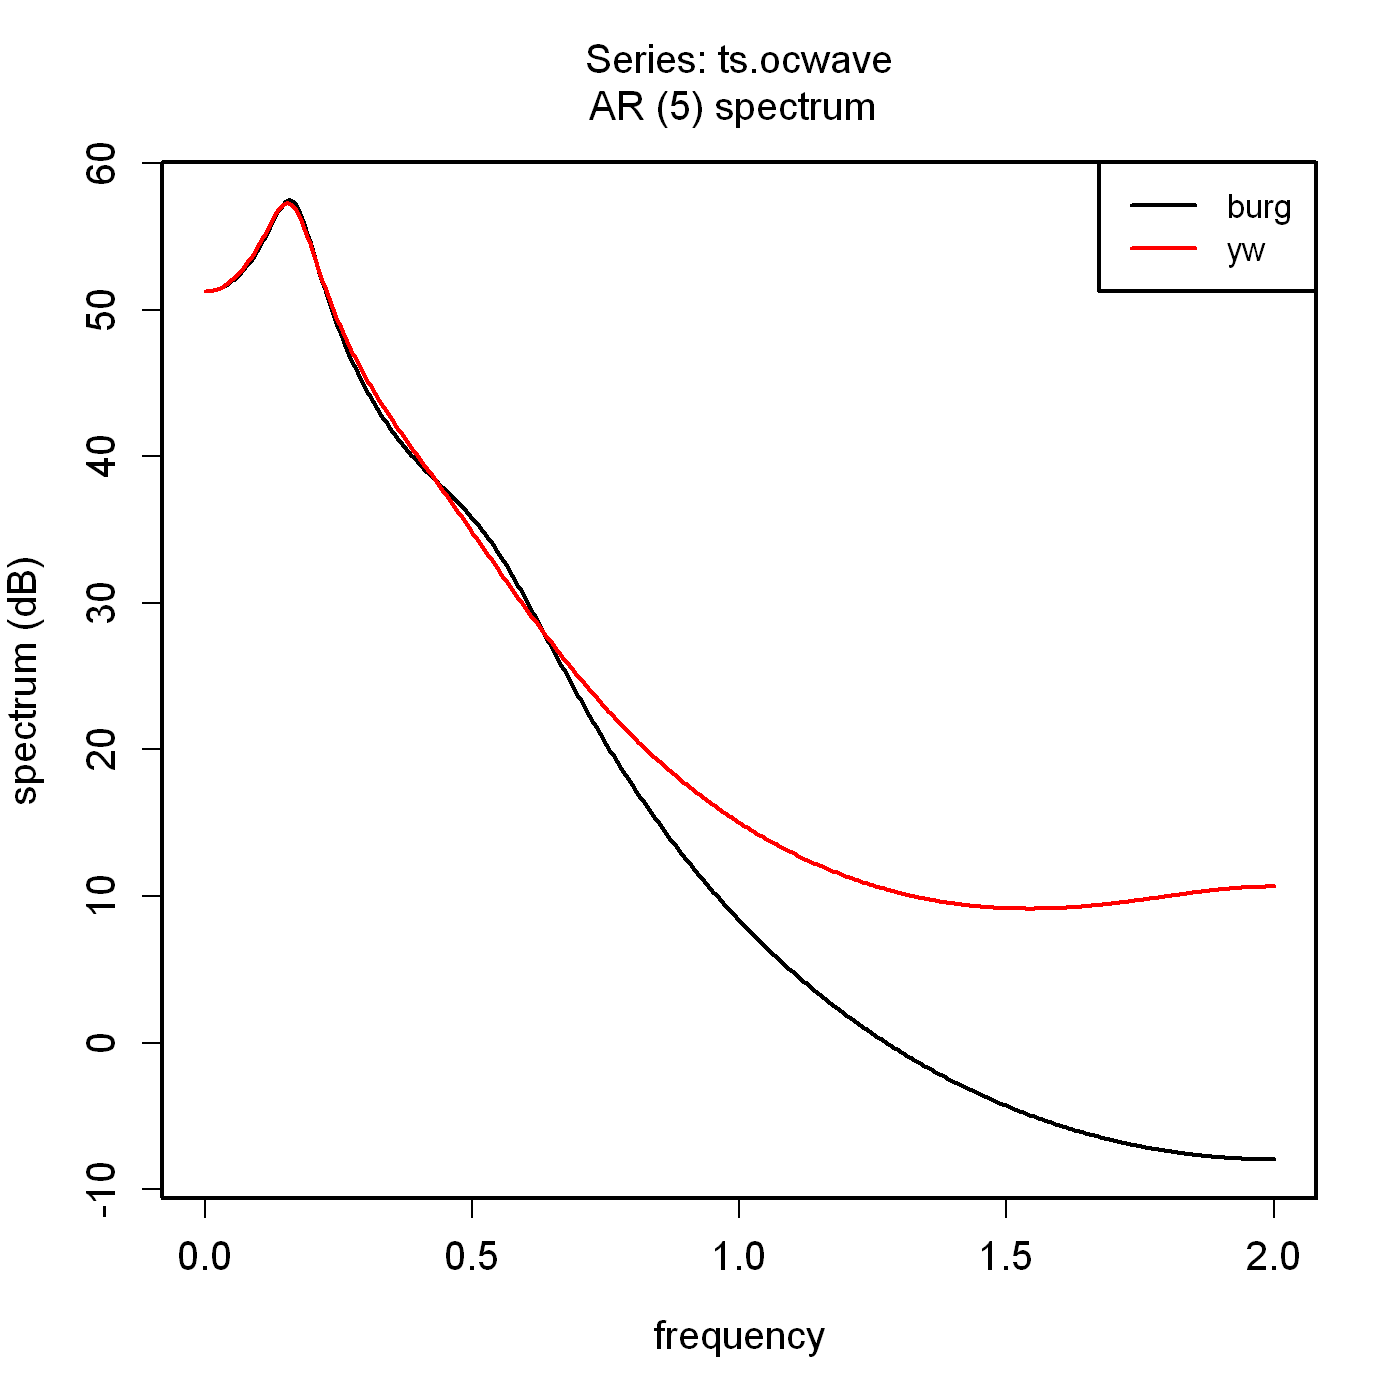

In [569]:
par(lwd = 2,mfrow = c(1,1), font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
spec.ar(ocwave.burg, plot = TRUE, log = "dB",lwd=2)
spec.ar(ocwave.yw, add = TRUE,log="dB",col="red",lwd=2)
legend("topright",legend = c("burg","yw"),col=c("black","red"),lty=c(1,1))

In [570]:
d.beluga <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/beluga.dat",
header=T)
d.beluga <- ts(d.beluga)

In [571]:
str(d.beluga)

 Time-Series [1:160, 1:5] from 1 to 160: 1 2 3 4 5 6 7 8 9 10 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:5] "PERIOD" "BOUTS" "NURSING" "LOCKONS" ...


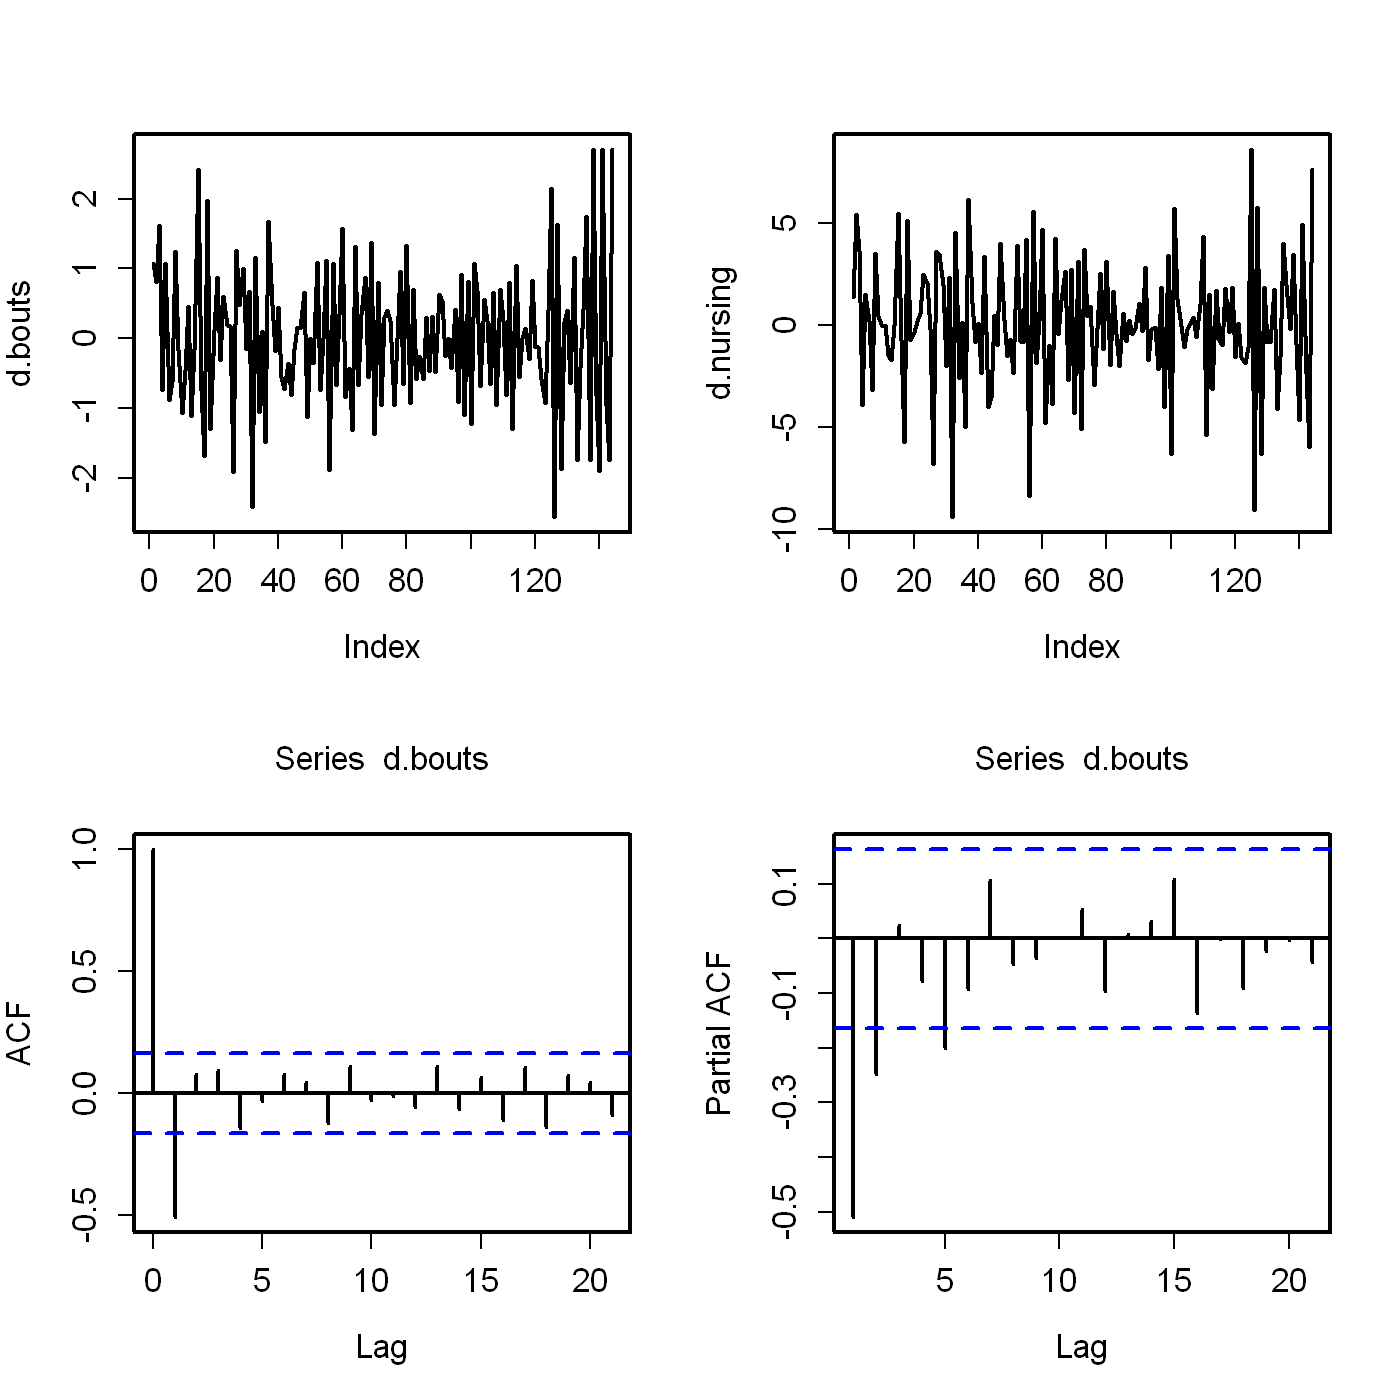

In [572]:
d.bouts <- na.omit(diff(d.beluga[6:150,4]))
d.nursing <- na.omit(diff(d.beluga[6:150,3]))

par(lwd = 2,mfrow = c(2,2), font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
plot(d.bouts,type="l")
plot(d.nursing,type="l")
acf(d.bouts)
pacf(d.bouts)

In [573]:
ar.fit <- arima(d.bouts,order = c(5,0,0))

In [574]:
ar.fit$coef[0:5]

ar1        ar2        ar3        ar4        ar5 
-0.7070967 -0.3224114 -0.1502059 -0.3080043 -0.2769134

In [579]:
x <- ts(d.bouts)
y <- ts(d.nursing)

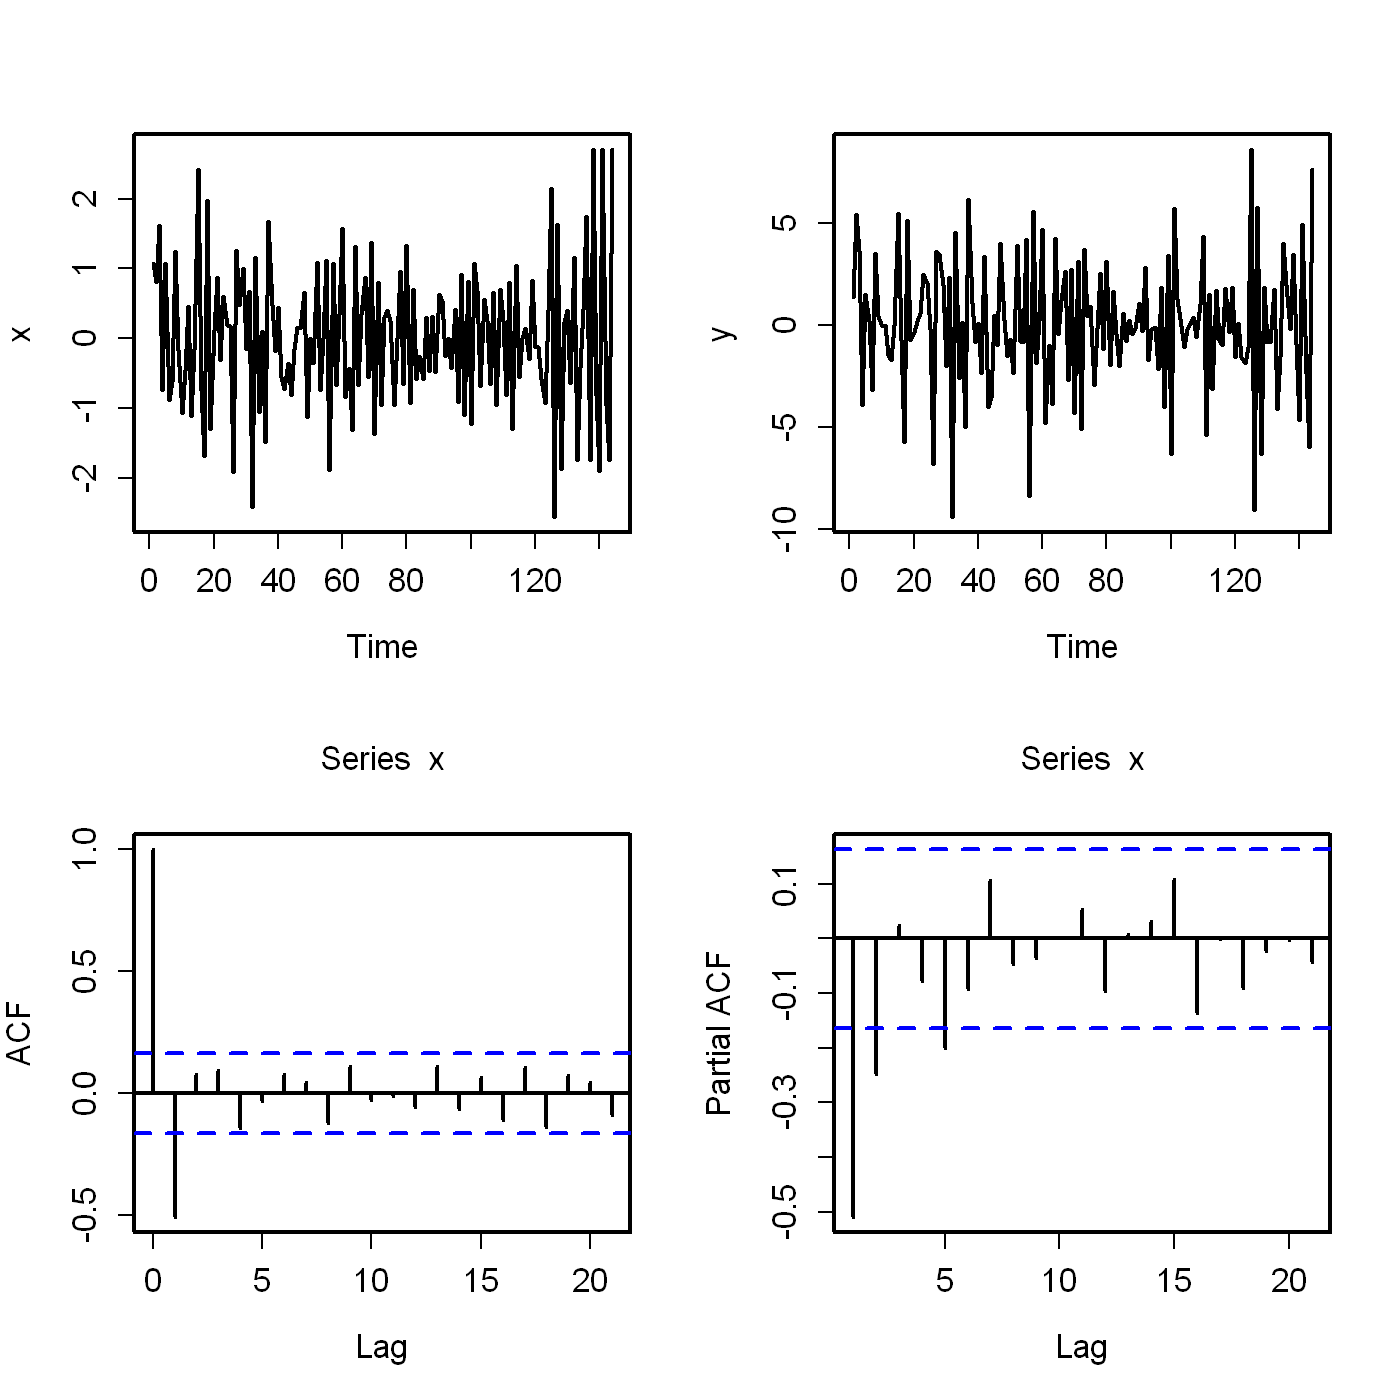

In [580]:

par(lwd = 2,mfrow = c(2,2), font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
plot(x,type="l")
plot(y,type="l")
acf(x)
pacf(x)

In [581]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

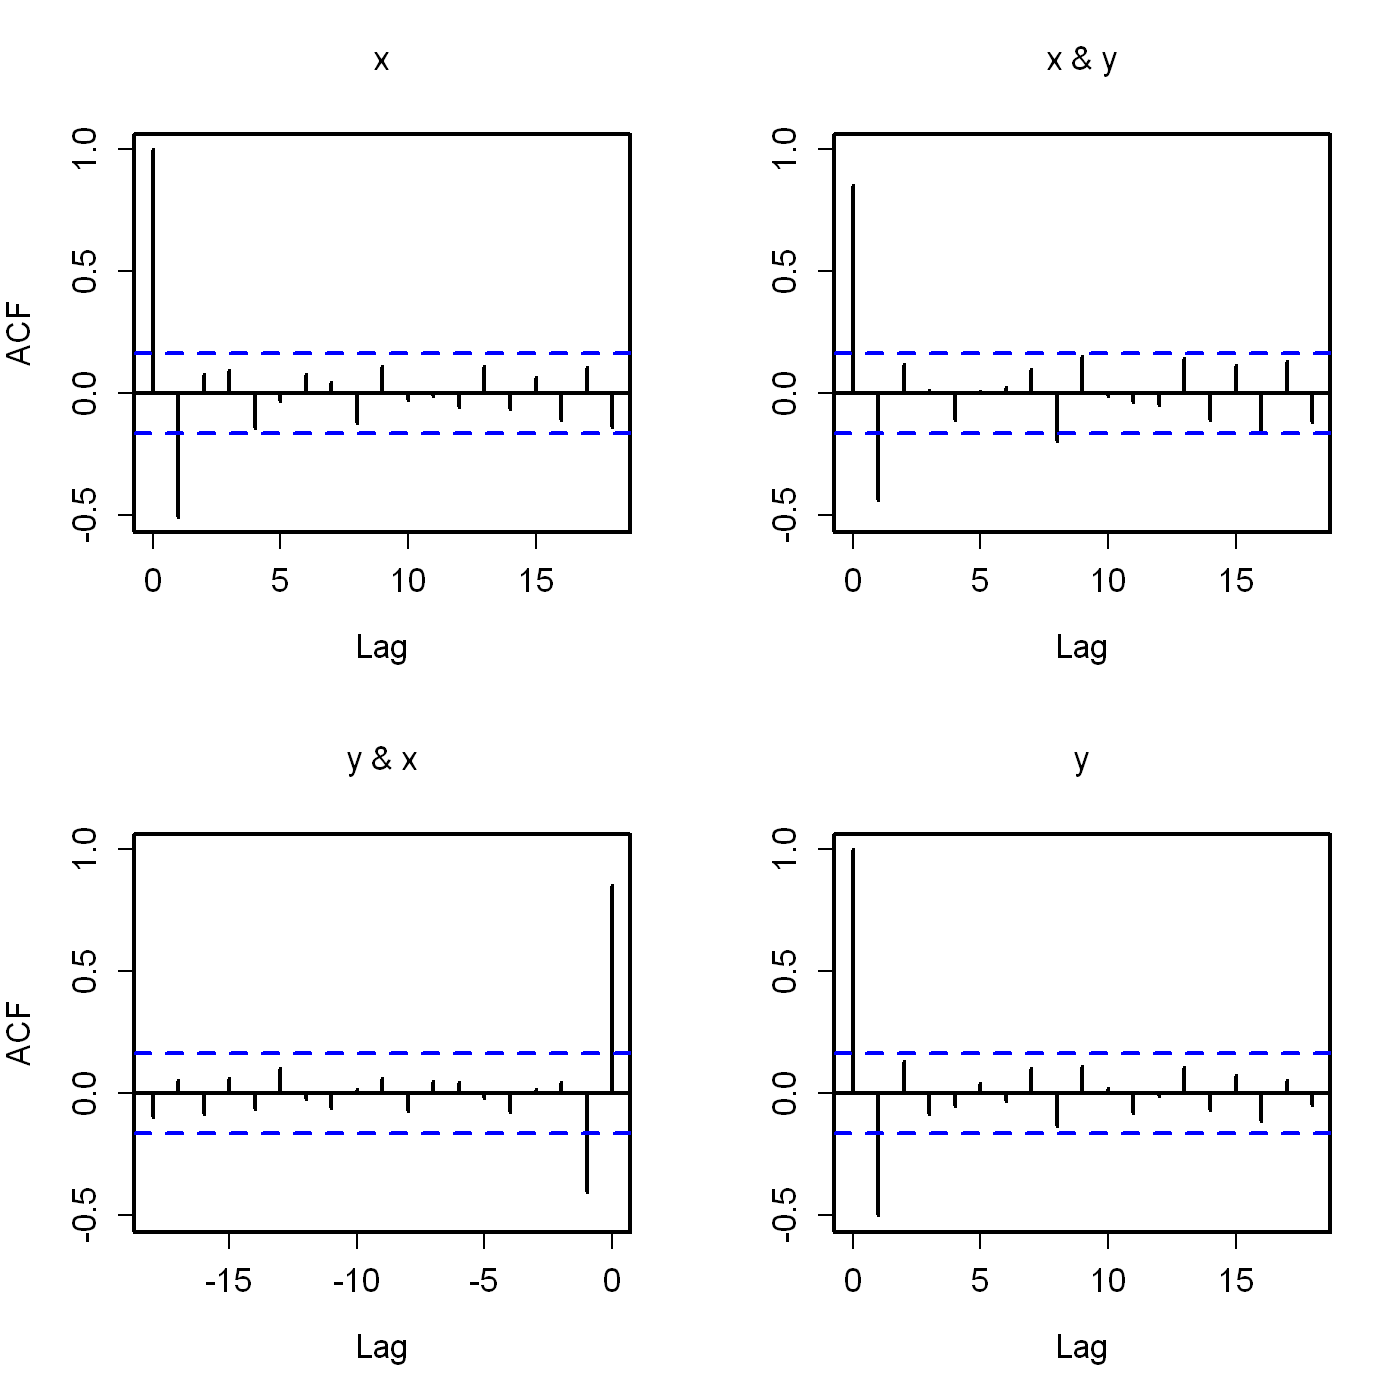

In [582]:
par(lwd = 2, font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
acf(ts.intersect(x,y),na.action = na.omit)

In [584]:
abs(polyroot(c(1,-0.8,0.2)))

[1] 2.236068 2.236068

In [596]:
AirPassengers

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336
1958,340,318,362,348,363,435,491,505,404,359,310,337


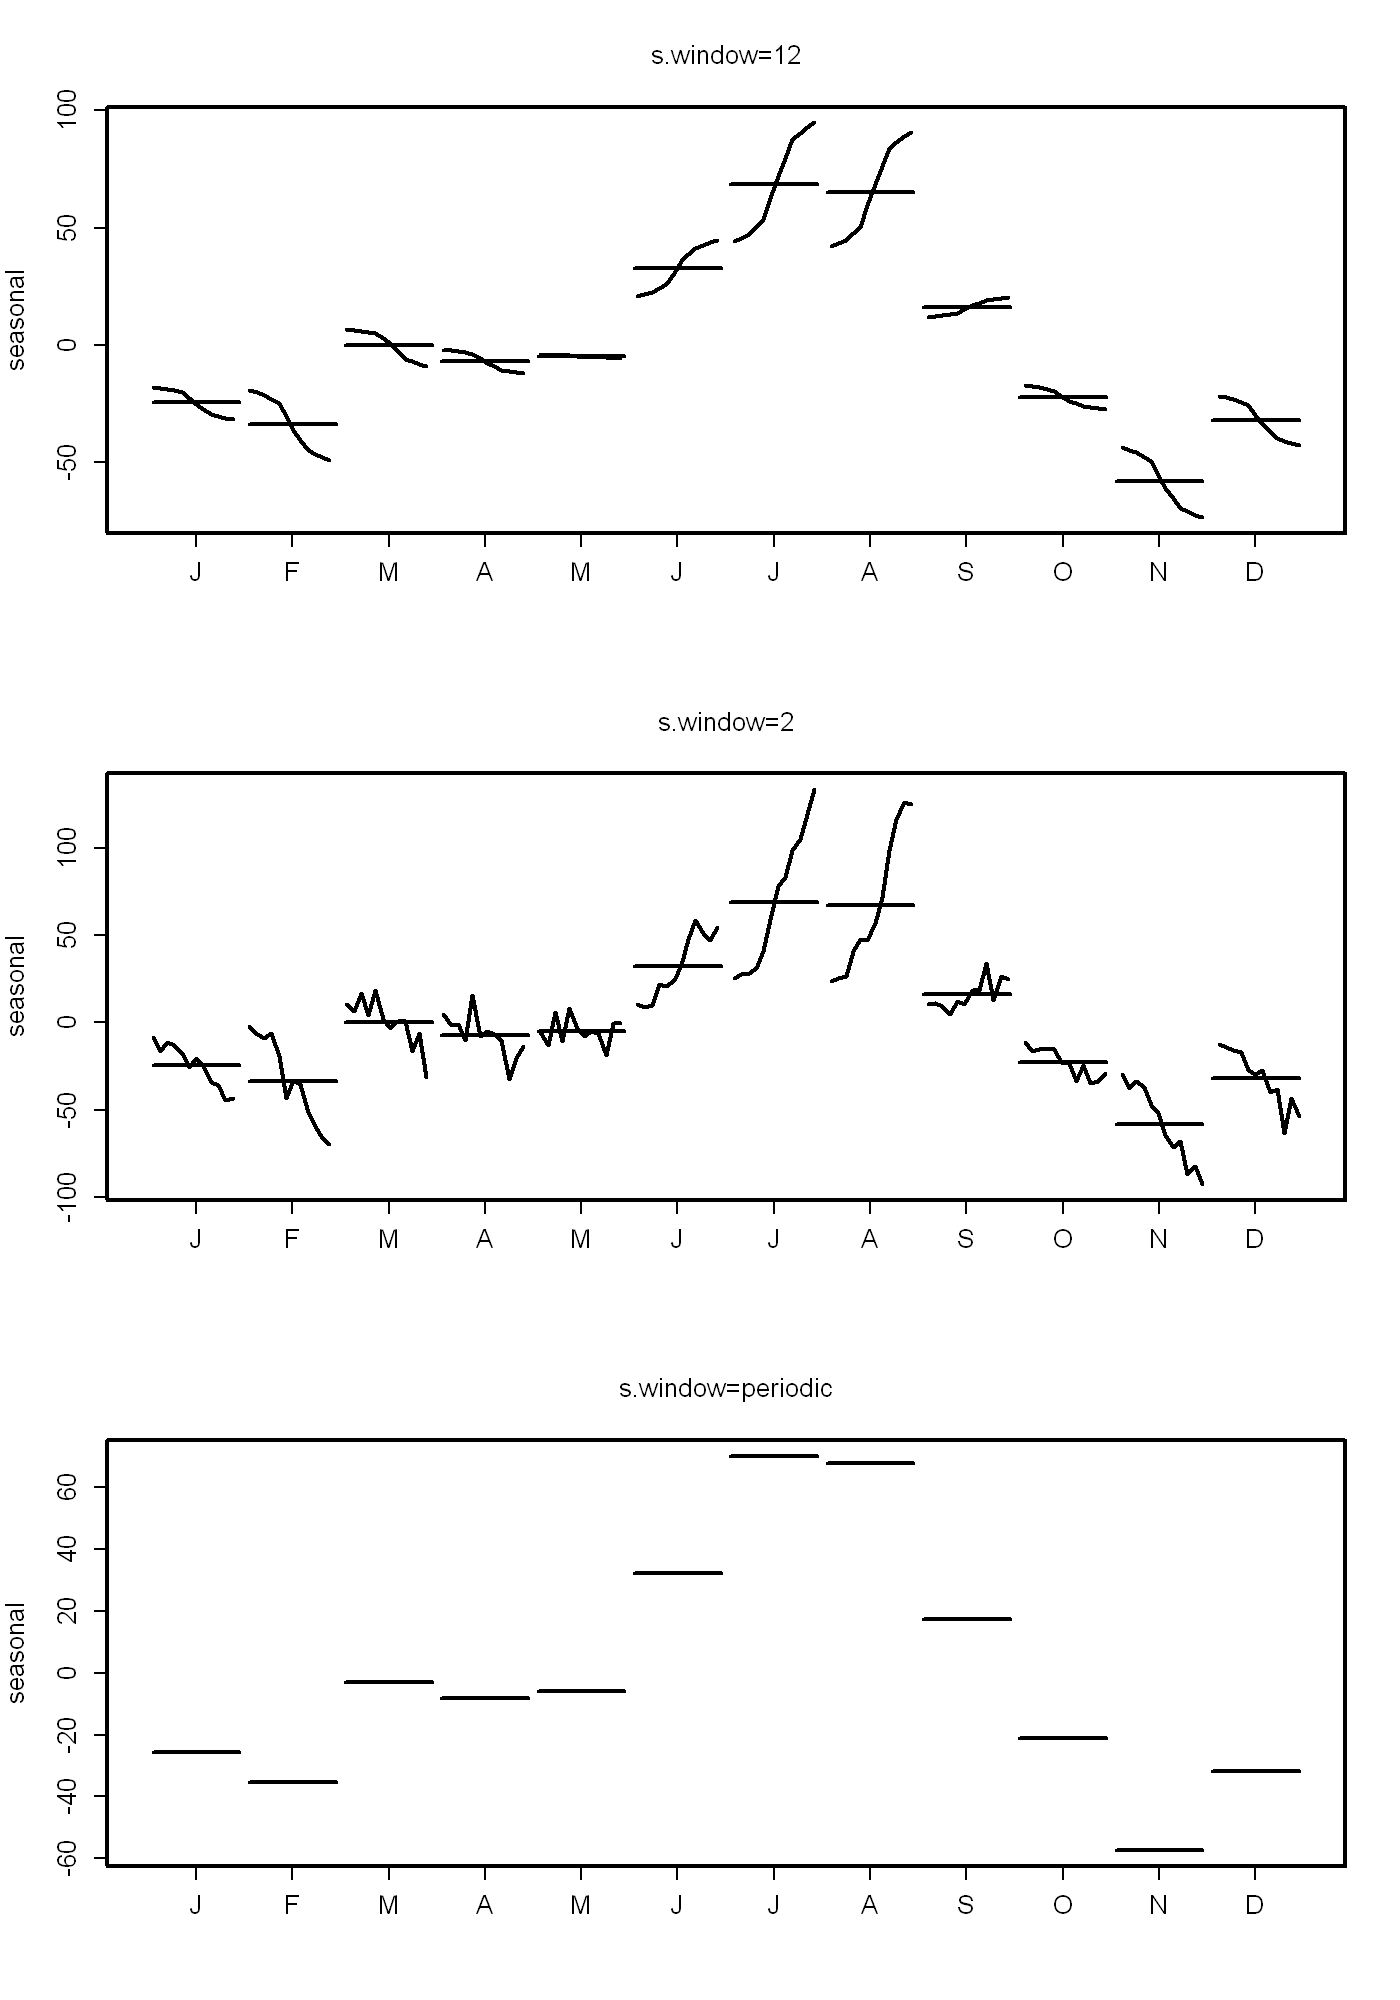

In [621]:
options(repr.plot.width = 7, repr.plot.height = 10, repr.plot.res = 200)
par(lwd = 2,mfrow=c(3,1), font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)
monthplot(stl(AirPassengers,s.window =12),main="s.window=12")
monthplot(stl(AirPassengers,s.window =2),main="s.window=2")
monthplot(stl(AirPassengers,s.window ="periodic"),main="s.window=periodic")


